# Predicting Airbnb Listing Prices in Brisbane, Australia__

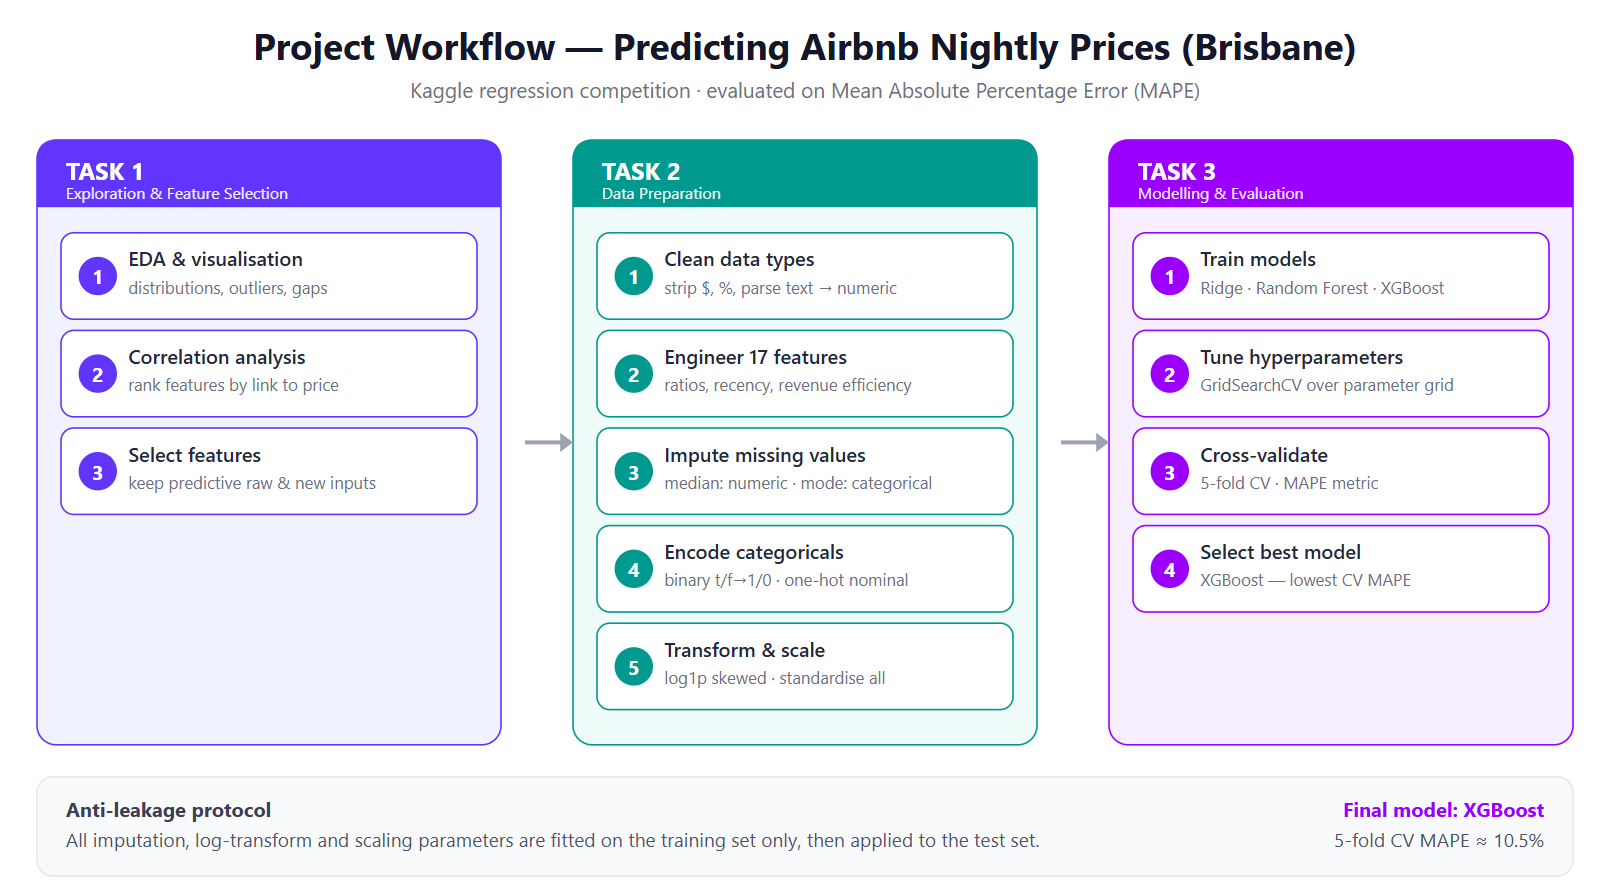

---
---

## Task 1: Problem Description and Exploratory Data Analysis (EDA)  





<hr style="width:25%;margin-left:0;">    

#### 1. Forecasting Problem (2 marks)  



This assignment asks us to predict the **nightly listing price (AUD)** for Airbnb properties located in Brisbane, Australia.
Each record represents one listing and describes the property's physical characteristics, host attributes, location, and historical review activity.

**Real-world applications:**

- **Hosts** can benchmark their asking price against similar listings and optimise rates to balance occupancy with revenue — a practice known as dynamic pricing.
- **Property investors** can assess short-term rental potential before acquiring an asset.
- **Airbnb/platform operators** use price predictions to power smart pricing tools and to detect anomalously priced listings.
- **Travellers** benefit from a well-calibrated market that surfaces fairly priced options.
- **Local governments and urban planners** can monitor pricing trends to understand tourism impacts and housing affordability pressures.

From a machine-learning perspective, this is a **supervised regression** problem: we learn a mapping from a set of observable listing features to a continuous target variable (price) using labelled training data, then apply the learned model to unseen test listings.
Accurate price prediction is commercially valuable — even modest improvements in pricing accuracy can substantially raise host revenue and platform transaction volume (Gibbs et al., 2018; Wang & Nicolau, 2017).


<hr style="width:25%;margin-left:0;">   

#### 2. Evaluation Criteria (2 marks)  
Describe the evaluation metric used in this competition to assess forecasting performance.  
Provide the equation and discuss its advantages and potential limitations.


The competition uses **Mean Absolute Percentage Error (MAPE)**:

$$\text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100\%$$

where $y_i$ is the actual price and $\hat{y}_i$ is the predicted price for listing $i$.

**Advantages:**
- *Scale-independent* — expressed as a percentage, predictions for cheap and expensive listings are penalised proportionally, making MAPE meaningful across the full price range.
- *Intuitive* — a MAPE of 10 % means predictions are, on average, 10 % from the true price.
- *Consistent with business objectives* — hosts care about relative accuracy; a $20 error matters more on a $100 listing than a $1,000 listing.

**Limitations:**
- *Near-zero denominator* — if $y_i \approx 0$ the metric is undefined or inflated. In this dataset the minimum price is $36, so this is a minor concern, though very cheap listings still receive disproportionately heavy penalties.
- *Asymmetric* — for the same absolute error, under-predictions receive a larger percentage penalty than over-predictions, which can bias models toward slight over-prediction.
- *Sensitive to outliers* — a few very cheap or very expensive listings can dominate the overall MAPE.


<hr style="width:25%;margin-left:0;">      

#### 3. Missing Values (2 marks)  
Identify and report the number of missing values in the dataset using appropriate summaries.  
Clearly interpret your findings for both the training and test datasets.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data 
train = pd.read_csv('Group-Project-S1-2026/train.csv')
test  = pd.read_csv('Group-Project-S1-2026/test.csv')    

print(f"Training set  : {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"Test set      : {test.shape[0]:,} rows × {test.shape[1]} columns")

# Training set missing values
miss_train = train.isnull().sum()
miss_train = miss_train[miss_train > 0].sort_values(ascending=False)
mpct_train = (miss_train / len(train) * 100).round(1)
miss_df_train = pd.DataFrame({'Missing Count': miss_train, 'Missing %': mpct_train})
print("--- Training Set ---")
print(miss_df_train.to_string())

# Test set missing values
miss_test = test.isnull().sum()
miss_test = miss_test[miss_test > 0].sort_values(ascending=False)
mpct_test = (miss_test / len(test) * 100).round(1)
miss_df_test = pd.DataFrame({'Missing Count': miss_test, 'Missing %': mpct_test})
print("\n--- Test Set ---")
print(miss_df_test.to_string())


Training set  : 3,735 rows × 65 columns
Test set      : 1,601 rows × 64 columns
--- Training Set ---
                             Missing Count  Missing %
host_neighbourhood                    3599       96.4
neighborhood_overview                 1981       53.0
host_about                            1492       39.9
host_location                          818       21.9
reviews_per_month                      437       11.7
review_scores_rating                   437       11.7
review_scores_accuracy                 437       11.7
review_scores_cleanliness              437       11.7
review_scores_checkin                  437       11.7
review_scores_communication            437       11.7
last_review                            437       11.7
first_review                           437       11.7
review_scores_location                 437       11.7
review_scores_value                    437       11.7
host_response_rate                     287        7.7
host_response_time                 

In [26]:
pd.set_option('display.max_columns', None)
print("TRAINING SET — First 20 rows")
train.head(20)

TRAINING SET — First 20 rows


,ID,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price
0,0,city scrape,The Nestt,Enjoy a memorable visit when you stay in this ...,NaN,38029254,Mark,2015-07-09,NaN,NaN,within an hour,100%,89%,t,NaN,8.0,"['email', 'phone', 'work_email']",t,t,Rocklea - Acacia Ridge,-27.557320,153.020270,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Hair dryer"", ""Hangers"", ""Fire extinguisher"",...",5,365,5.0,5.0,365.0,365.0,5.0,365.0,12,30,53,328,18,10,1,30,4,100,9700.0,2023-04-27,2025-10-25,4.56,4.61,4.44,4.78,4.61,4.28,4.50,f,8,8,0,0,0.58,$97.00
1,1,city scrape,Bayside Bliss - By the Water & Near the Airport,"Relax by the water and close to the airport, B...",Wynnum is nestled along Brisbane's sunny south...,33488214,Claire,2015-05-16,"Wynnum, Australia",NaN,within an hour,100%,93%,t,NaN,1.0,"['email', 'phone']",t,t,Wynnum,-27.445790,153.179090,Entire guest suite,Entire home/apt,4,1.0,1 bath,2.0,3.0,"[""Laundromat nearby"", ""Refrigerator"", ""Bed lin...",1,14,1.0,1.0,14.0,14.0,1.0,14.0,14,15,45,110,16,8,1,14,10,48,9840.0,2024-06-16,2025-11-02,4.94,4.88,5.00,4.94,4.94,4.88,4.69,f,1,1,0,0,0.93,$205.00
2,2,city scrape,Cozy 1 Bedroom Apartment with Infinity Pool,My stunning apartment is located in one of the...,Staying here allows you to experience the neve...,401146490,Hao,2021-05-11,NaN,"Roger and I love traveling, we fell in love wi...",within an hour,100%,100%,f,NaN,7.0,['phone'],t,t,Fortitude Valley,-27.456050,153.032450,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Refrigerator"", ""Essentials"", ""Dishwasher"", ""...",1,365,1.0,2.0,365.0,365.0,1.3,365.0,10,31,50,131,27,16,0,22,17,96,17856.0,2024-03-11,2025-10-11,4.70,4.70,4.67,4.70,4.81,4.67,4.56,t,7,7,0,0,1.33,$186.00
3,3,city scrape,City Stay-Executive 1.5 Bedroom,Experience modern urban living in our stylish ...,NaN,83183834,John,2016-07-11,"Hamilton, Australia",NaN,within an hour,100%,100%,f,NaN,1.0,"['email', 'phone']",t,t,Newstead - Bowen Hills,-27.451701,153.035454,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,2.0,"[""Outdoor shower"", ""Exercise equipment"", ""Refr...",21,730,21.0,21.0,730.0,730.0,21.0,730.0,0,0,0,224,0,0,0,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN,$157.00
4,4,city scrape,Private Oasis! 3Bed/2Bath/1Car ~ 5mins to CBD,Brisbane inner-city living at its best! <br />...,Location (walking)<br /><br />•\t1 min e-Scoot...,3384506,Andy,2012-08-27,"Brisbane, Australia",Brisbane’s Leading Property Management Company...,within an hour,100%,97%,t,NaN,155.0,"['email', 'phone']",t,t,Fortitude Valley,-27.458774,153.038180,Entire rental unit,Entire home/apt,6,2.0,2 baths,3.0,3.0,"[""Refrigerator"", ""Stainless steel single oven""...",7,365,2.0,7.0,365.0,1125.0,6.2,746.0,7,18,31,31,23,23,3,17,0,255,76500.0,2025-04-09,2025-11-09,4.74,4.87,4.87,4.78,4.87,4.83,4.57,f,132,132,0,0,3.18,$300.00
5,5,city scrape,Ladies only 

**Interpretation:**

The training set has 65 columns and 3,735 records. Of these, 33 columns contain at least one missing value.

Key observations:
- `host_neighbourhood` is almost entirely missing (~96 %) and is excluded from modelling.
- `neighborhood_overview` and `host_about` are free-text fields with 40–53 % missingness; they are dropped.
- All seven `review_scores_*` columns and `reviews_per_month` have exactly 437 missing values (~11.7 %), corresponding to listings that have never received a review — they will be median-imputed.
- `host_response_rate` and `host_acceptance_rate` have ~5–8 % missingness and will also be median-imputed.
- Core structural features (`bathrooms`, `bedrooms`, `beds`) have fewer than 6 missing values each — straightforward to impute with the median.


<hr style="width:25%;margin-left:0;">      

#### 4. Univariate Data Analysis (2 marks)  
Present and discuss key *univariate* characteristics of the training data.  
Use appropriate summary statistics and visualisations (e.g. histograms for numerical variables, bar charts for categorical variables) to support your analysis.  
For example you may consider variables such as price, room type, number of listings per host, availability, or geographical location.

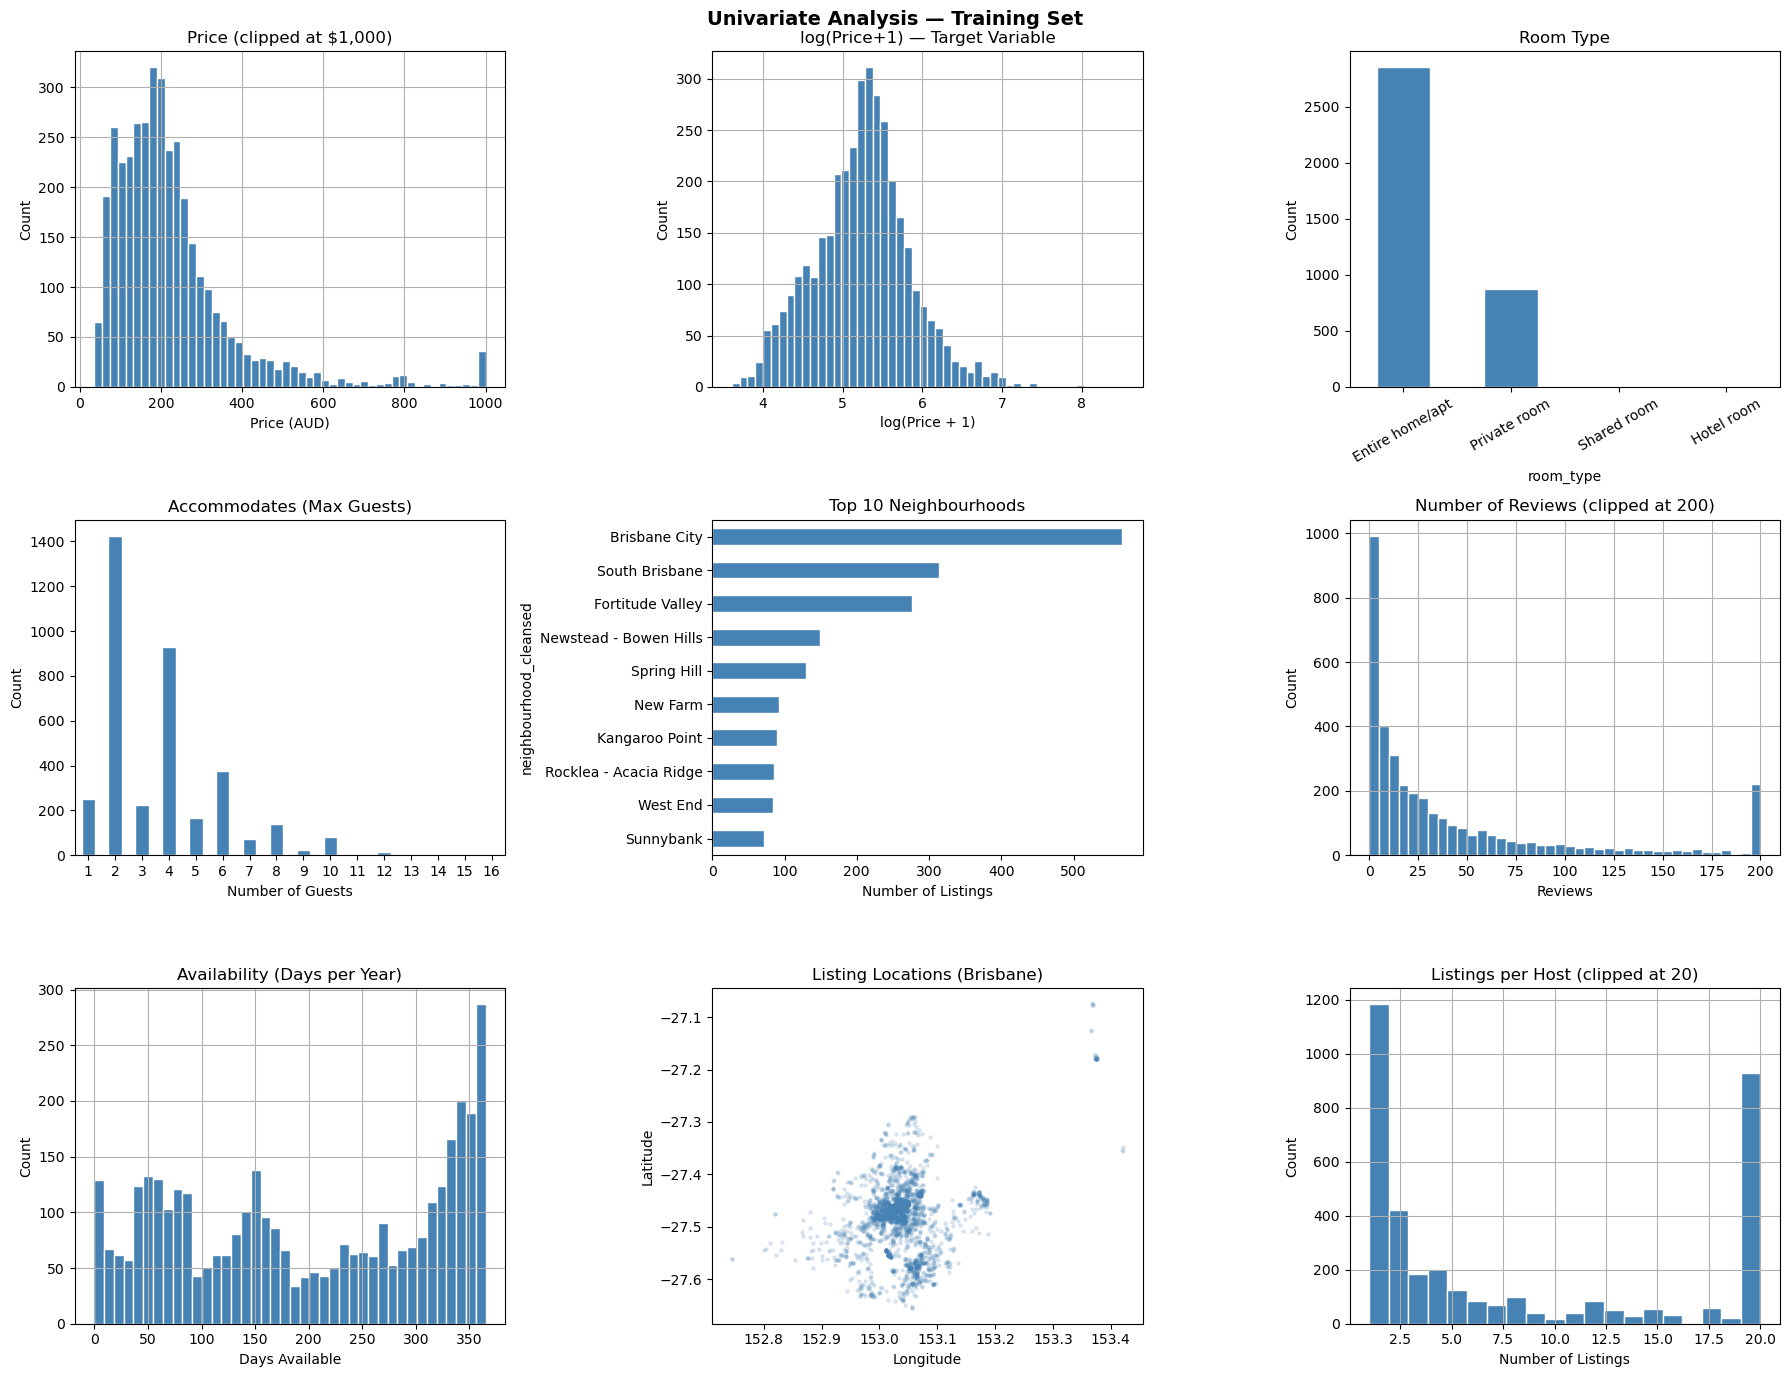


Price summary statistics:
count    3735.00
mean      230.08
std       194.65
min        36.00
25%       129.00
50%       193.00
75%       267.00
max      5000.00
Name: price_num, dtype: float64


In [29]:

# Parse price
train['price_num'] = train['price'].str.replace(r'[\$,]', '', regex=True).astype(float)

# Create the 3x3 grid ONCE
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Univariate Analysis — Training Set', fontsize=14, fontweight='bold')

# ── Plot 1: Price distribution ────────────────────────────────────────────────
ax = axes[0, 0]
train['price_num'].clip(upper=1000).hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Price (clipped at $1,000)')
ax.set_xlabel('Price (AUD)'); ax.set_ylabel('Count')

# ── Plot 2: Log-price distribution ───────────────────────────────────────────
ax = axes[0, 1]
np.log1p(train['price_num']).hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('log(Price+1) — Target Variable')
ax.set_xlabel('log(Price + 1)'); ax.set_ylabel('Count')

# ── Plot 3: Room type ─────────────────────────────────────────────────────────
ax = axes[0, 2]
train['room_type'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Room Type'); ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)

# ── Plot 4: Accommodates ──────────────────────────────────────────────────────
ax = axes[1, 0]
train['accommodates'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Accommodates (Max Guests)')
ax.set_xlabel('Number of Guests'); ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)

# ── Plot 5: Top 10 Neighbourhoods ─────────────────────────────────────────────
ax = axes[1, 1]
(train['neighbourhood_cleansed'].value_counts().head(10)
 .sort_values()
 .plot(kind='barh', ax=ax, color='steelblue', edgecolor='white'))
ax.set_title('Top 10 Neighbourhoods')
ax.set_xlabel('Number of Listings')

# ── Plot 6: Number of reviews ─────────────────────────────────────────────────
ax = axes[1, 2]
train['number_of_reviews'].clip(upper=200).hist(
    bins=40, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Number of Reviews (clipped at 200)')
ax.set_xlabel('Reviews'); ax.set_ylabel('Count')

# ── Plot 7: Availability ──────────────────────────────────────────────────────
ax = axes[2, 0]
train['availability_365'].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Availability (Days per Year)')
ax.set_xlabel('Days Available'); ax.set_ylabel('Count')

# ── Plot 8: Geographical location ────────────────────────────────────────────
ax = axes[2, 1]
ax.scatter(train['longitude'], train['latitude'],
           alpha=0.15, s=5, color='steelblue')
ax.set_title('Listing Locations (Brisbane)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

# ── Plot 9: Listings per host ─────────────────────────────────────────────────
ax = axes[2, 2]
train['calculated_host_listings_count'].clip(upper=20).hist(
    bins=20, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Listings per Host (clipped at 20)')
ax.set_xlabel('Number of Listings'); ax.set_ylabel('Count')

# ── Save and show ONCE at the very end ───────────────────────────────────────
plt.tight_layout()
plt.savefig('eda_univariate.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPrice summary statistics:")
print(train['price_num'].describe().round(2))

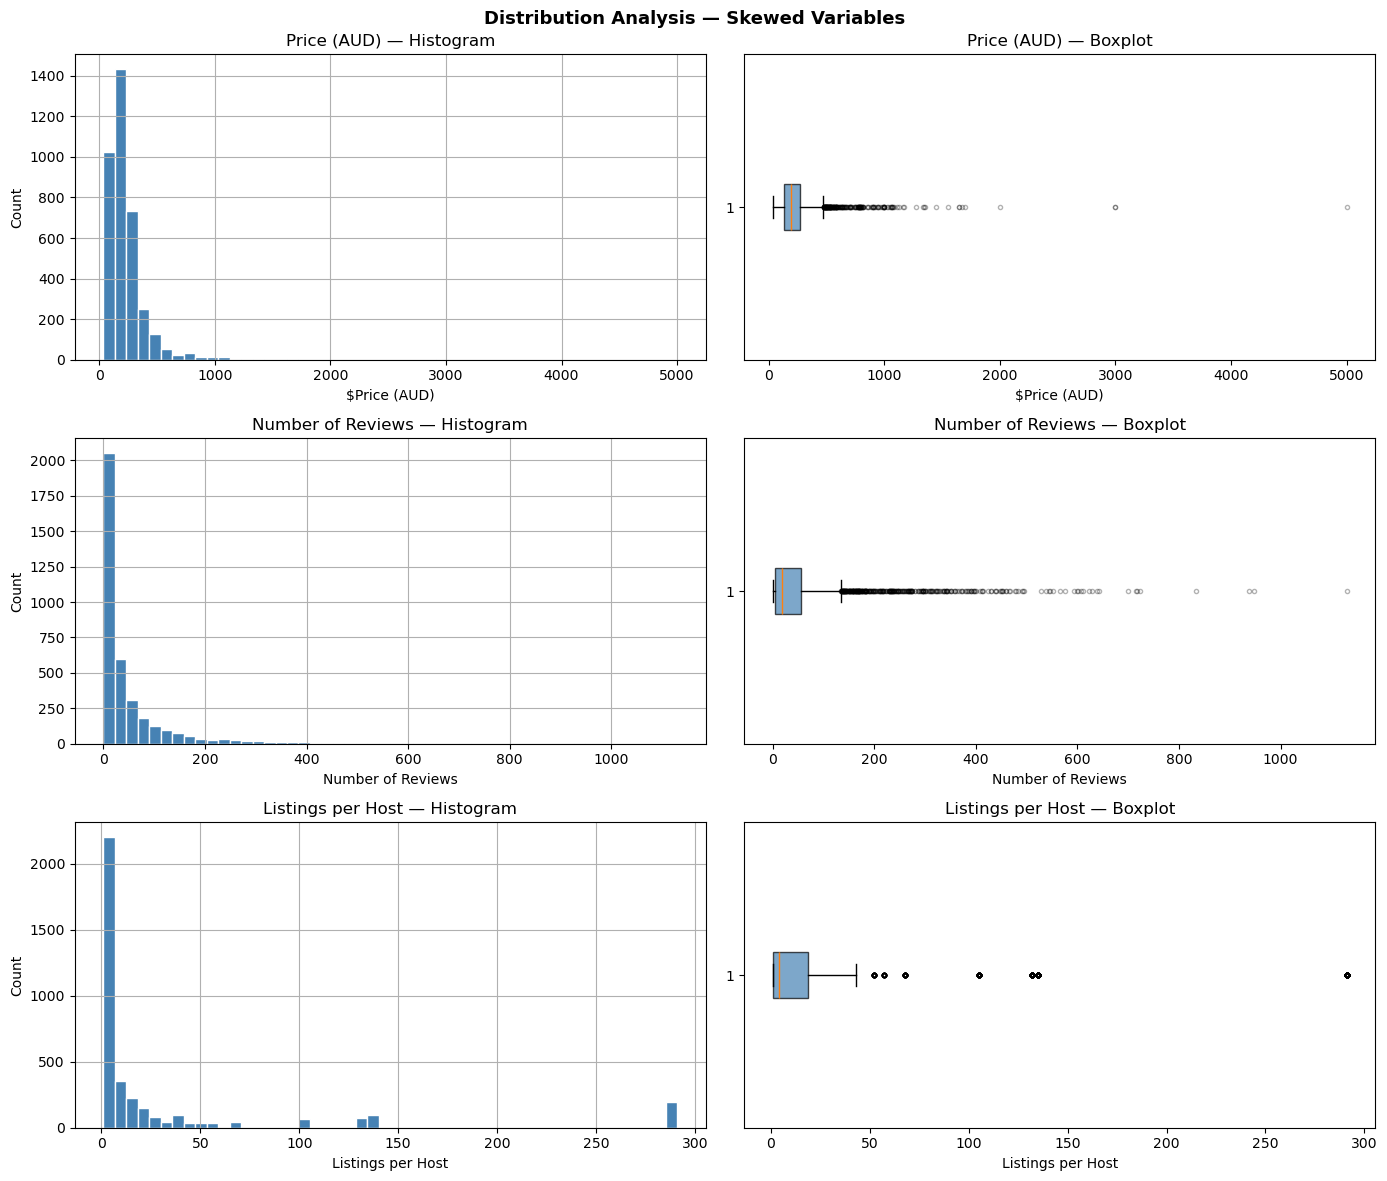

In [30]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Distribution Analysis — Skewed Variables', fontsize=13, fontweight='bold')

skewed_vars = [
    ('price_num',                      'Price (AUD)',           '$'),
    ('number_of_reviews',              'Number of Reviews',     ''),
    ('calculated_host_listings_count', 'Listings per Host',     ''),
]

for i, (col, label, prefix) in enumerate(skewed_vars):
    
    # Left column — histogram (full data, no clipping)
    ax = axes[i, 0]
    train[col].hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{label} — Histogram')
    ax.set_xlabel(f'{prefix}{label}')
    ax.set_ylabel('Count')

    # Right column — boxplot (shows outliers honestly)
    ax = axes[i, 1]
    ax.boxplot(train[col].dropna(), vert=False, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7),
               flierprops=dict(marker='o', markersize=3, alpha=0.3))
    ax.set_title(f'{label} — Boxplot')
    ax.set_xlabel(f'{prefix}{label}')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Find listings with availability_365 = 0
zero_avail = train[train['availability_365'] == 0]
print(zero_avail[['number_of_reviews', 'estimated_occupancy_l365d', 
                   'minimum_nights', 'price_num']].describe())

       number_of_reviews  estimated_occupancy_l365d  minimum_nights  \
count          53.000000                  53.000000       53.000000   
mean           45.867925                  64.245283        1.830189   
std            64.357785                  81.611393        1.490171   
min             0.000000                   0.000000        1.000000   
25%             7.000000                   0.000000        1.000000   
50%            19.000000                  18.000000        1.000000   
75%            50.000000                 108.000000        2.000000   
max           292.000000                 255.000000        7.000000   

         price_num  
count    53.000000  
mean    301.660377  
std     254.411534  
min      36.000000  
25%     170.000000  
50%     214.000000  
75%     352.000000  
max    1449.000000  


**Discussion:**

- **Price** is heavily right-skewed (mean ~$230, median ~$193, max $5,000). The log-transformed distribution is approximately normal, motivating a log transformation of the target before regression modelling.
- **Room type**: ~76 % entire home/apartment, ~23 % private rooms — the dataset is dominated by whole-property lets.
- **Accommodates**: most listings accommodate 2–4 guests, consistent with the prevalence of couples and small family/friend groups in short-stay travel.
- **Neighbourhoods**: Brisbane City, South Brisbane, and Fortitude Valley hold the highest listing counts, reflecting inner-city tourism concentration.
- **Reviews**: right-skewed with many listings having fewer than 20 reviews, indicating a large share of newer or infrequently booked properties.


<hr style="width:25%;margin-left:0;">   

#### 5. Feature Analysis and Selection (2 marks)  
Select at least 20 meaningful features from the dataset.  

- Categorise each feature according to its variable type and present the results in a table (similar to Assignment 1)  
- Analyse how key features relate to the target variable (*price*) using appropriate plots and/or summary statistics  
- Justify your feature selection based on your analysis  
---



| Variable Type | Number of Features | Feature Names |
| --- | --- | --- |
| Numeric | 25 | accommodates, bedrooms, beds, host_listings_count, availability_365, minimum_nights, bathrooms, latitude, longitude, host_response_rate, host_acceptance_rate, review_scores_rating, review_scores_cleanliness, review_scores_location, review_scores_accuracy, review_scores_checkin, review_scores_communication, review_scores_value, estimated_occupancy_l365d, estimated_revenue_l365d, availability_365, availability_30, number_of_reviews, number_of_reviews_ltm, number_of_reviews_l30d |
| Binary | 3 | host_is_superhost, host_identity_verified, instant_bookable |
| Nominal | 3 | neighbourhood_cleansed, room_type, property_type |
| Date | 2 | host_since, last_review |
| Text/List | 2 | amenities, host_response_time |

In [35]:
#For visualisation purposes, percentage symbols were removed from host_response_rate and host_acceptance_rate to allow numerical plotting. Full numerical cleaning is performed in Task 2.
# Parse percentage columns
train['host_response_rate_num'] = train['host_response_rate'].str.replace('%', '', regex=False).astype(float)
train['host_acceptance_rate_num'] = train['host_acceptance_rate'].str.replace('%', '', regex=False).astype(float)
selected = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'latitude', 'longitude', 'neighbourhood_cleansed',
    'room_type', 'property_type', 'host_is_superhost',
    'host_response_rate_num', 'host_acceptance_rate_num',
    'host_listings_count', 'host_identity_verified',
    'availability_365', 'minimum_nights', 'instant_bookable',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'estimated_occupancy_l365d',
    'host_since',         # → will become host_tenure_days
    'last_review',        # → will become days_since_last_review
    'amenities',          # → will become amenities_count, has_wifi, has_pool
    'number_of_reviews',  # → used directly and as engineering base
    'estimated_revenue_l365d',                          # → revenue_per_* (strongest signal)
    'availability_365', 'availability_30',              # → availability_pressure, occupancy_pressure
    'number_of_reviews_ltm', 'number_of_reviews_l30d',  # → review_momentum, recent_review_ratio
    'host_response_time',                               # → response_time_score (raw col dropped after mapping)
    'review_scores_accuracy', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_value',  # → review_variability
]

print(train[selected].dtypes)
print("\nObject columns:")
print(train[selected].select_dtypes(include='object').columns.tolist())

accommodates                     int64
bedrooms                       float64
beds                           float64
bathrooms                      float64
latitude                       float64
longitude                      float64
neighbourhood_cleansed          object
room_type                       object
property_type                   object
host_is_superhost               object
host_response_rate_num         float64
host_acceptance_rate_num       float64
host_listings_count            float64
host_identity_verified          object
availability_365                 int64
minimum_nights                   int64
instant_bookable                object
review_scores_rating           float64
review_scores_cleanliness      float64
review_scores_location         float64
estimated_occupancy_l365d        int64
host_since                      object
last_review                     object
amenities                       object
number_of_reviews                int64
estimated_revenue_l365d  

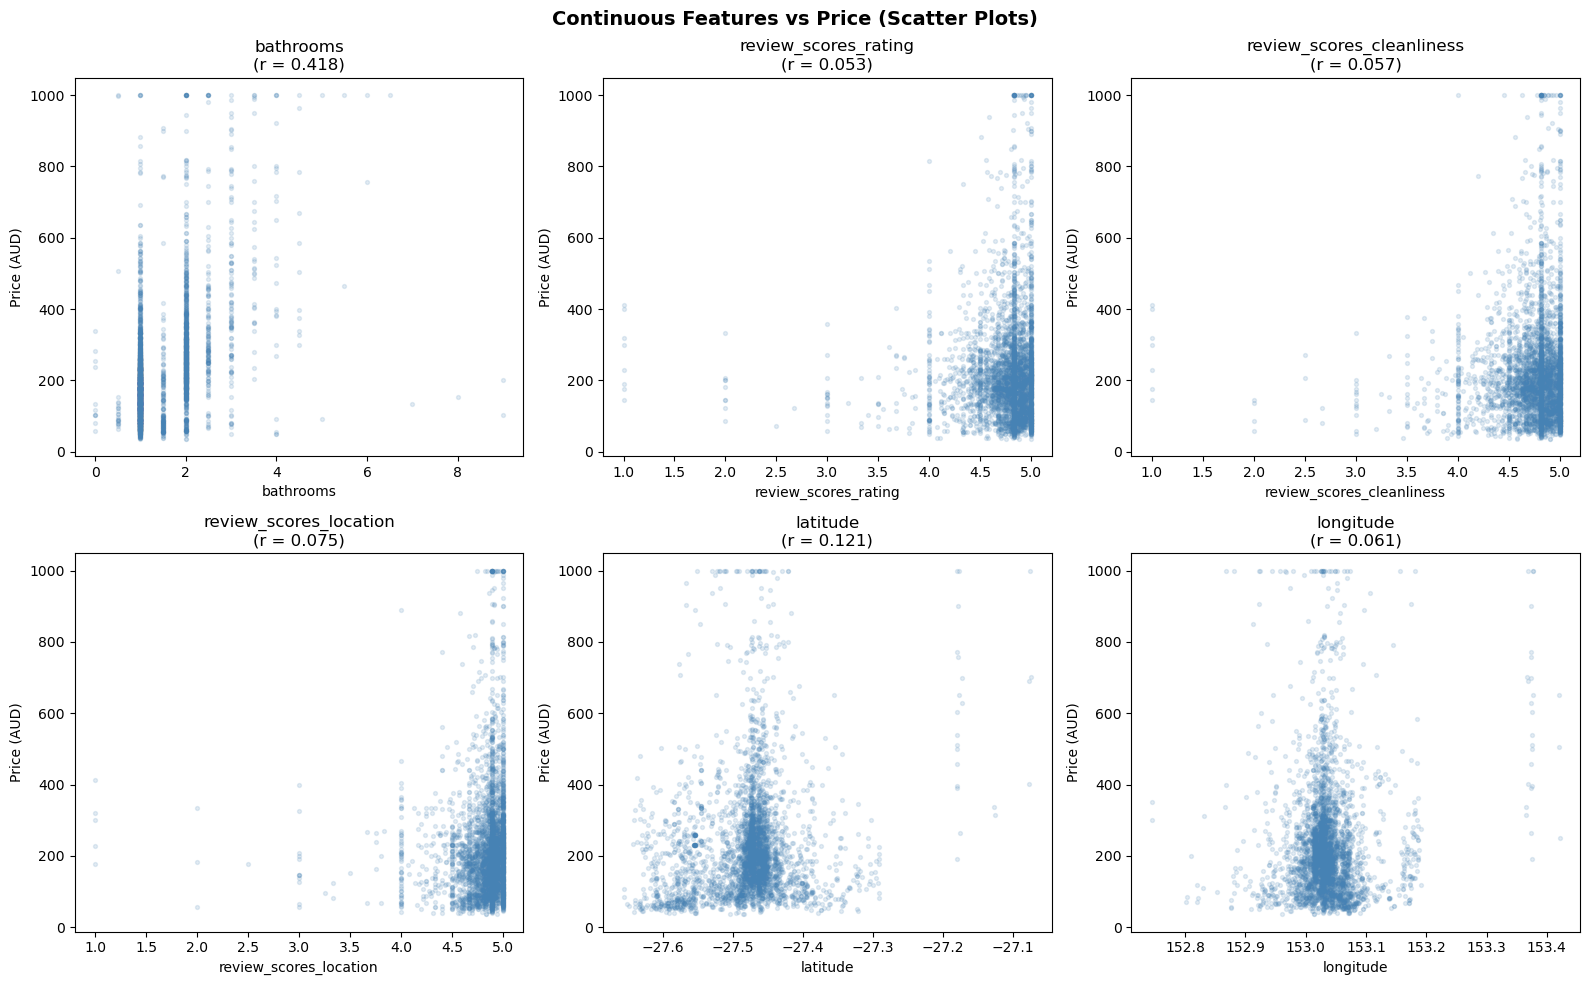

In [36]:
# ═══════════════════════════════════════════════════════════════════
# SECTION 1 — CONTINUOUS FEATURES vs PRICE (Scatter plots)
# Only bathrooms and location features are truly continuous
# ═══════════════════════════════════════════════════════════════════
continuous_features = [
    'bathrooms',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'latitude',
    'longitude'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Continuous Features vs Price (Scatter Plots)', 
             fontsize=14, fontweight='bold')

for i, col in enumerate(continuous_features):
    ax = axes[i // 3, i % 3]
    x = train[col].fillna(train[col].median())
    y = train['price_num'].clip(upper=1000)
    
    ax.scatter(x, y, alpha=0.15, s=8, color='steelblue')
    
    # Correlation coefficient
    corr = np.corrcoef(x, train['price_num'].fillna(0))[0, 1]
    ax.set_title(f'{col}\n(r = {corr:.3f})')
    ax.set_xlabel(col)
    ax.set_ylabel('Price (AUD)')

plt.tight_layout()
plt.savefig('scatter_continuous_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

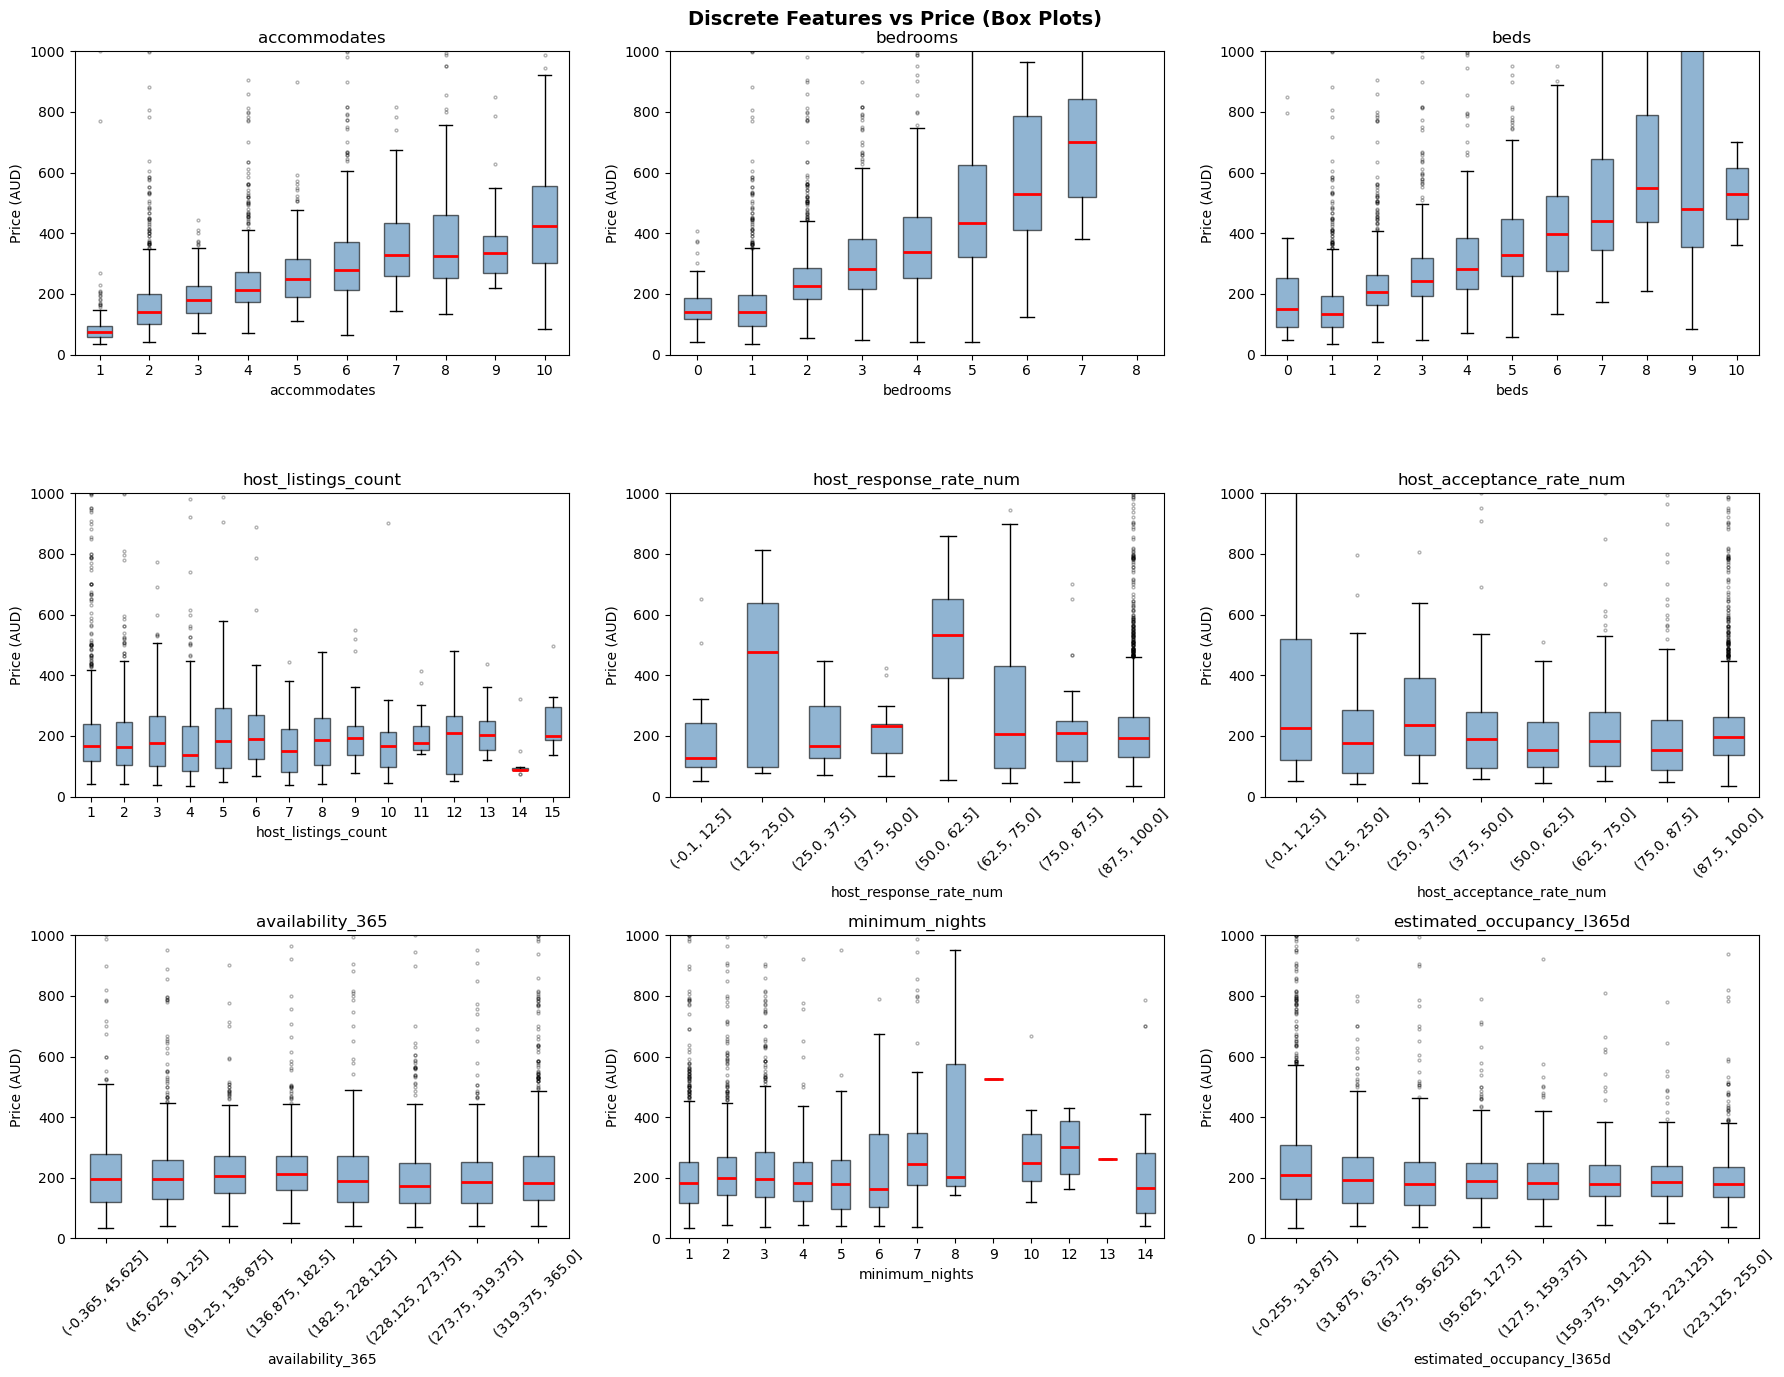

In [37]:
# ═══════════════════════════════════════════════════════════════════
# SECTION 2 — DISCRETE FEATURES vs PRICE (Box plots)
# ═══════════════════════════════════════════════════════════════════

# Each tuple is (column name, max value to show, x label rotation)
discrete_features = [
    ('accommodates',             10,   0),
    ('bedrooms',                  8,   0),
    ('beds',                     10,   0),
    ('host_listings_count',      15,   0),
    ('host_response_rate_num',  100, 45),
    ('host_acceptance_rate_num',100, 45),
    ('availability_365',        None,  45),
    ('minimum_nights',           14,  0),
    ('estimated_occupancy_l365d', None, 45),
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Discrete Features vs Price (Box Plots)', 
             fontsize=14, fontweight='bold')

for i, (col, max_val, rotation) in enumerate(discrete_features):
    ax = axes[i // 3, i % 3]
    
    # Filter to reasonable range
    if max_val:
        data = train[train[col] <= max_val].copy()
    else:
        data = train.copy()
    
    # For columns with too many unique values, bin them
    n_unique = data[col].nunique()
    
    if n_unique > 15:
        # Create bins instead of showing every value
        data['binned'] = pd.cut(data[col], bins=8)
        groups = [grp['price_num'].dropna().values
                  for _, grp in data.groupby('binned', observed=True)]
        labels = [str(b) for b in sorted(data['binned'].dropna().unique())]
    else:
        groups = [grp['price_num'].dropna().values
                  for _, grp in data.groupby(col)]
        labels = [str(int(v)) for v in sorted(data[col].dropna().unique())]
    
    # Remove empty groups
    valid = [(g, l) for g, l in zip(groups, labels) if len(g) > 0]
    groups, labels = zip(*valid) if valid else ([], [])
    
    if groups:
        ax.boxplot(
    groups,
    tick_labels=labels,
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    medianprops=dict(color='red', linewidth=2)
)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Price (AUD)')
    ax.set_ylim(0, 1000)
    ax.tick_params(axis='x', rotation=rotation)

plt.tight_layout()
plt.savefig('boxplot_discrete_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

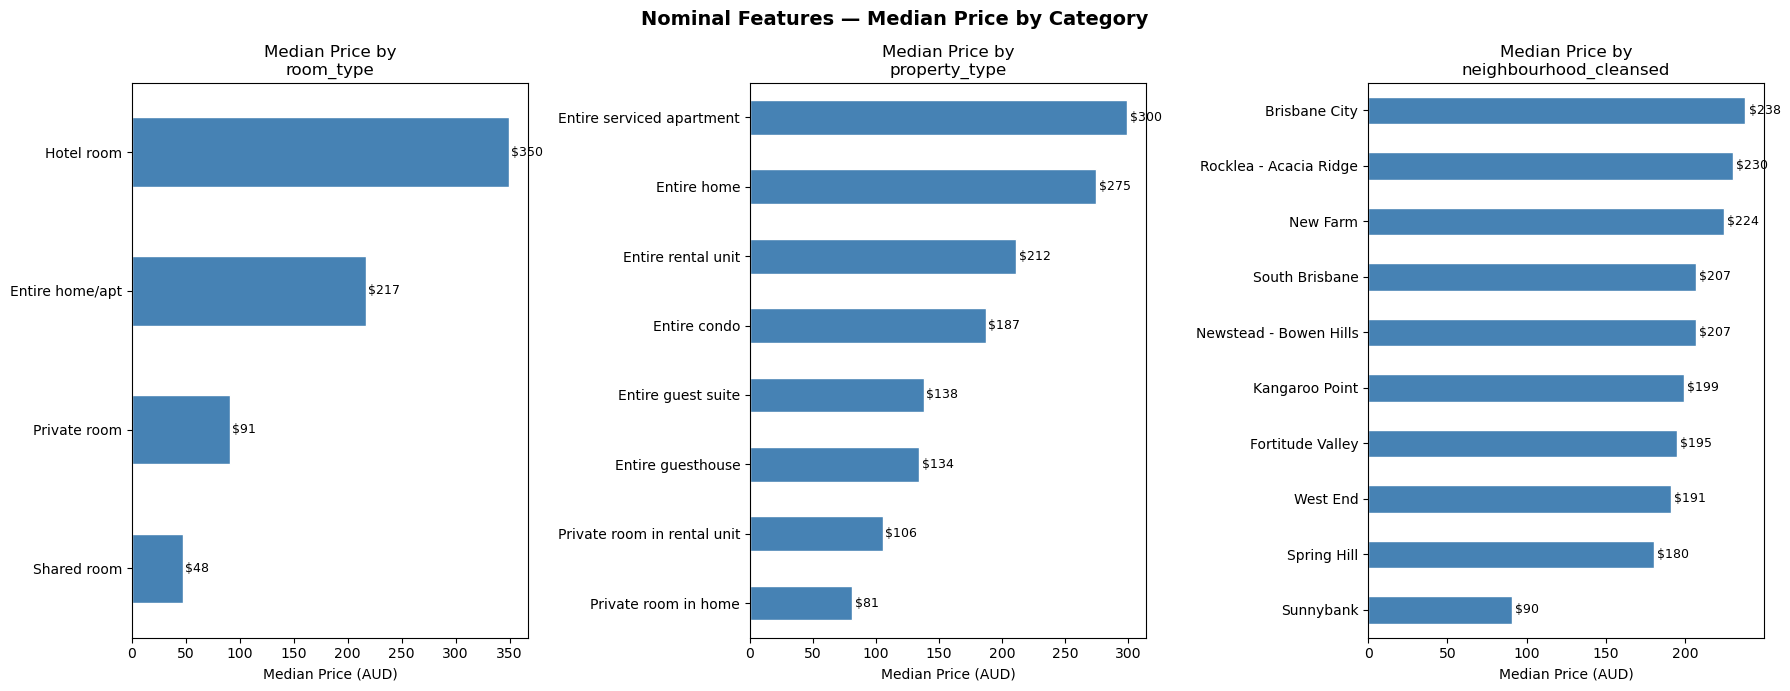

In [38]:
# ═══════════════════════════════════════════════════════════════════
# SECTION 3 — NOMINAL FEATURES vs PRICE 
# (Horizontal bar charts of median price)
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Nominal Features — Median Price by Category', 
             fontsize=14, fontweight='bold')

nominal_features = [
    ('room_type',              None),
    ('property_type',          8),
    ('neighbourhood_cleansed', 10),
]

for i, (col, top_n) in enumerate(nominal_features):
    ax = axes[i]
    
    # Get top N categories by listing count
    if top_n:
        top_cats = train[col].value_counts().head(top_n).index
        data = train[train[col].isin(top_cats)]
    else:
        data = train.copy()
    
    # Calculate median price per category, sorted
    median_price = (data.groupby(col)['price_num']
                    .median()
                    .sort_values(ascending=True))
    
    median_price.plot(kind='barh', ax=ax, 
                      color='steelblue', edgecolor='white')
    
    ax.set_title(f'Median Price by\n{col}')
    ax.set_xlabel('Median Price (AUD)')
    ax.set_ylabel('')
    
    # Add price labels on each bar
    for j, v in enumerate(median_price.values):
        ax.text(v + 2, j, f'${v:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('barplot_nominal_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

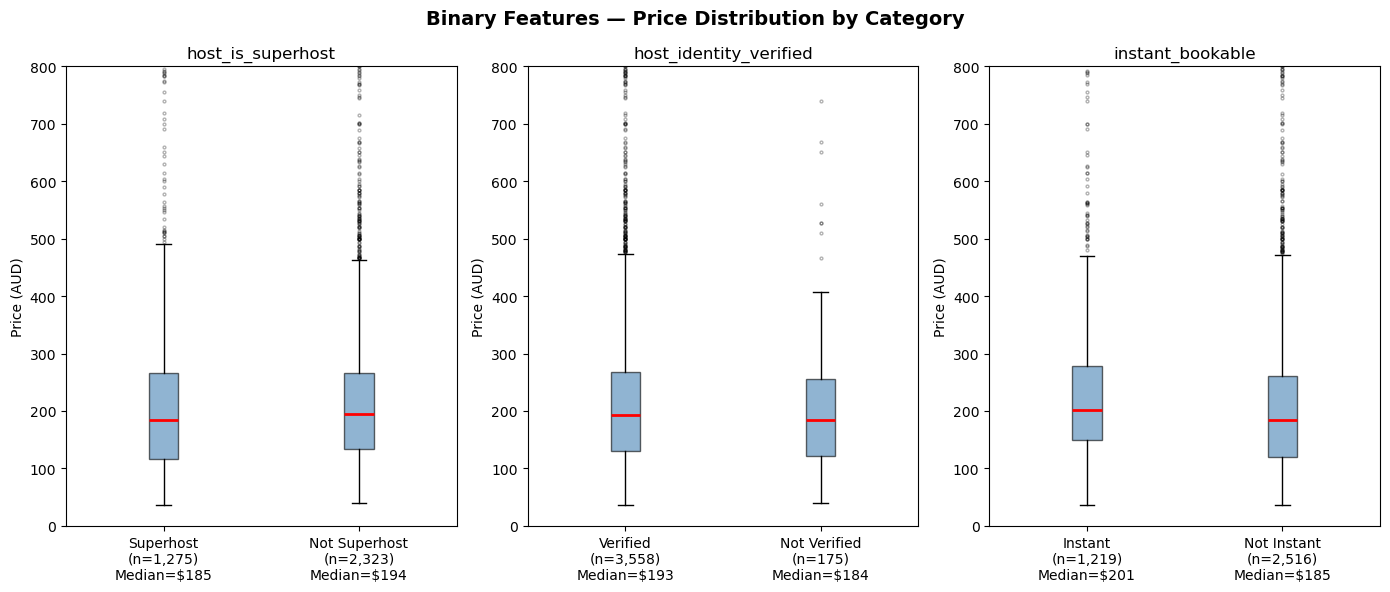

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

fig.suptitle(
    'Binary Features — Price Distribution by Category',
    fontsize=14,
    fontweight='bold'
)

binary_features = [
    ('host_is_superhost', {'t': 'Superhost', 'f': 'Not Superhost'}),
    ('host_identity_verified', {'t': 'Verified', 'f': 'Not Verified'}),
    ('instant_bookable', {'t': 'Instant', 'f': 'Not Instant'})
]

for i, (col, label_map) in enumerate(binary_features):
    ax = axes[i]

    groups = []
    labels = []

    for val, label in label_map.items():
        prices = train[train[col] == val]['price_num'].dropna()

        groups.append(prices.values)

        n = len(prices)
        median = prices.median()

        labels.append(f"{label}\n(n={n:,})\nMedian=${median:.0f}")

    ax.boxplot(
        groups,
        tick_labels=labels,
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6),
        flierprops=dict(marker='o', markersize=2, alpha=0.3),
        medianprops=dict(color='red', linewidth=2)
    )

    ax.set_title(col)
    ax.set_ylabel('Price (AUD)')
    ax.set_ylim(0, 800)

plt.tight_layout()
plt.savefig('boxplot_binary_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# ============================================================
# SECTION 5 — CORRELATION TABLE
# Numeric features ranked by correlation with price
# ============================================================

# Make sure price_num exists
if 'price_num' not in train.columns:
    train['price_num'] = pd.to_numeric(
        train['price'].astype(str).str.replace(r'[$,]', '', regex=True),
        errors='coerce'
    )

numeric_for_corr = [
   'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'host_response_rate_num', 'host_acceptance_rate_num',
    'host_listings_count', 'availability_365', 'minimum_nights',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'estimated_occupancy_l365d',
    'latitude', 'longitude', 'price_num'
]

# Keep only columns that exist
numeric_for_corr = [c for c in numeric_for_corr if c in train.columns]

# Convert all selected columns to numeric safely
corr_data = train[numeric_for_corr].copy()

for col in numeric_for_corr:
    corr_data[col] = pd.to_numeric(
        corr_data[col].astype(str).str.replace(r'[$,%]', '', regex=True),
        errors='coerce'
    )

# Fill missing values using median of numeric columns
corr_data = corr_data.fillna(corr_data.median(numeric_only=True))

price_corr = (
    corr_data.corr(numeric_only=True)['price_num']
    .drop('price_num')
    .sort_values(key=abs, ascending=False)
    .round(3)
)

print("=" * 50)
print("Correlation with Price — ranked strongest to weakest")
print("=" * 50)
print(price_corr.to_string())

Correlation with Price — ranked strongest to weakest
accommodates                 0.523
bedrooms                     0.503
beds                         0.488
bathrooms                    0.418
latitude                     0.121
estimated_occupancy_l365d   -0.111
host_listings_count          0.082
host_response_rate_num      -0.077
review_scores_location       0.075
host_acceptance_rate_num    -0.073
longitude                    0.061
review_scores_cleanliness    0.057
review_scores_rating         0.053
availability_365             0.008
minimum_nights               0.006


In [41]:
# Temporary engineering for EDA visualisation purposes only
# Reference date = Kaggle competition start date (20 March 2026)

# host_tenure_days
train['host_tenure_days_temp'] = (
    pd.to_datetime('2026-03-20') - 
    pd.to_datetime(train['host_since'], errors='coerce')
).dt.days

# days_since_last_review
train['days_since_last_review_temp'] = (
    pd.to_datetime('2026-03-20') - 
    pd.to_datetime(train['last_review'], errors='coerce')
).dt.days

# amenities_count
train['amenities_count_temp'] = (
    train['amenities']
    .apply(lambda x: 0 if pd.isna(x) or x == '[]' 
           else len(str(x).split(',')))
)

In [42]:
print("host_tenure_days summary:")
print(train['host_tenure_days_temp'].describe().round(0))

print("\ndays_since_last_review summary:")
print(train['days_since_last_review_temp'].describe().round(0))

# Check a few specific rows to verify manually
print("\nSample verification:")
check = train[['host_since', 'host_tenure_days_temp', 
               'last_review', 'days_since_last_review_temp']].head(5)
print(check.to_string())

host_tenure_days summary:
count    3733.0
mean     2793.0
std      1356.0
min       130.0
25%      1420.0
50%      3130.0
75%      3766.0
max      6064.0
Name: host_tenure_days_temp, dtype: float64

days_since_last_review summary:
count    3298.0
mean      225.0
std       282.0
min       129.0
25%       140.0
50%       152.0
75%       193.0
max      3815.0
Name: days_since_last_review_temp, dtype: float64

Sample verification:
   host_since  host_tenure_days_temp last_review  days_since_last_review_temp
0  2015-07-09                 3907.0  2025-10-25                        146.0
1  2015-05-16                 3961.0  2025-11-02                        138.0
2  2021-05-11                 1774.0  2025-10-11                        160.0
3  2016-07-11                 3539.0         NaN                          NaN
4  2012-08-27                 4953.0  2025-11-09                        131.0


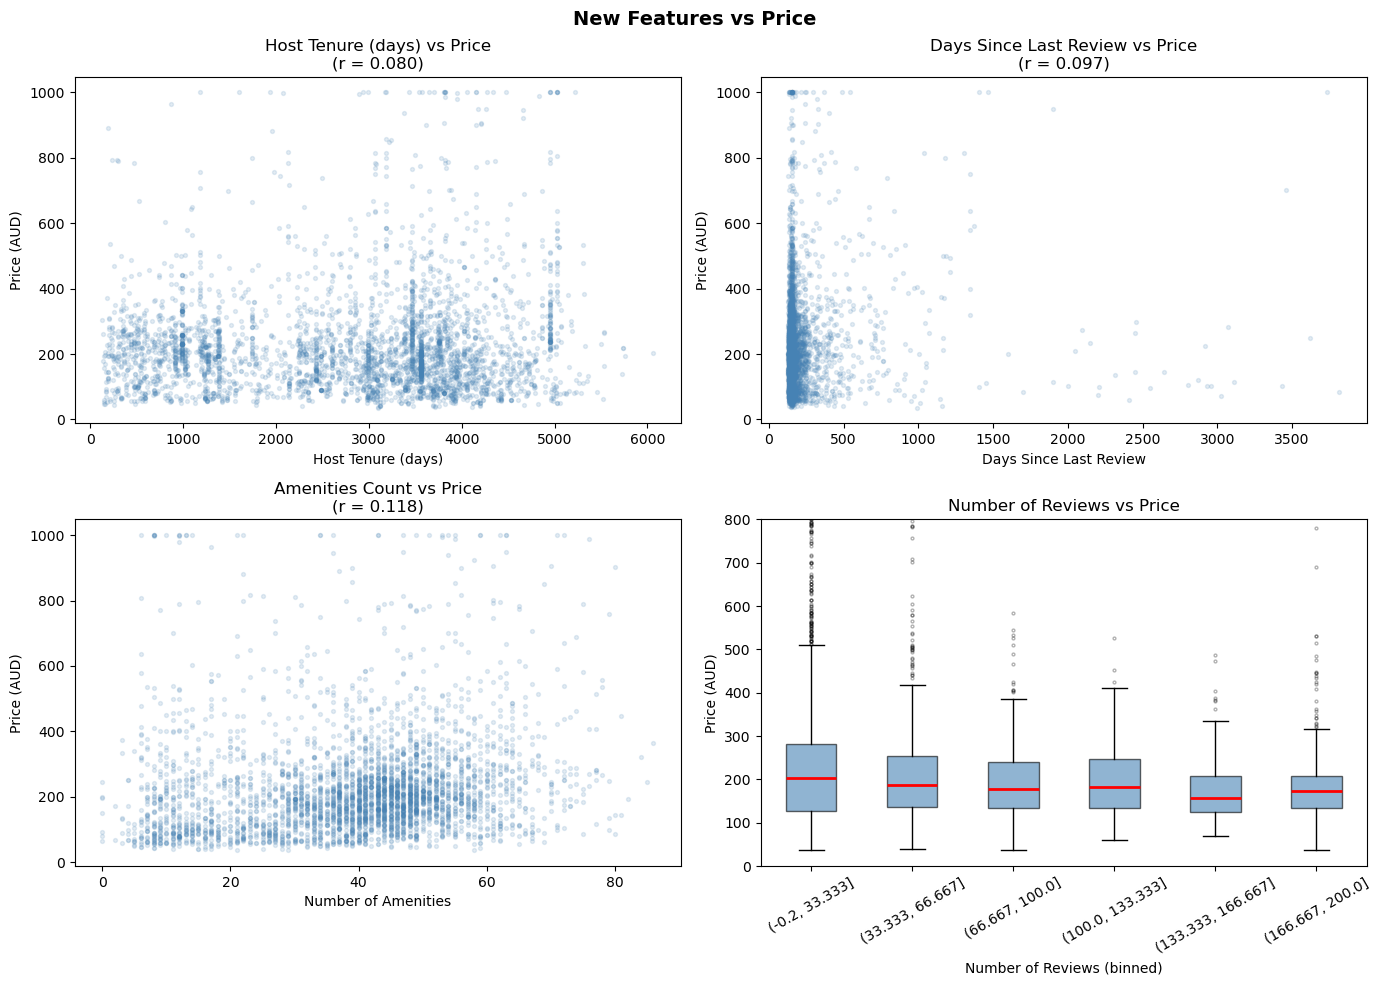

Correlation with Price — New Features
amenities_count_temp                : 0.118
days_since_last_review_temp         : 0.097
number_of_reviews                   : -0.082
host_tenure_days_temp               : 0.08


In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('New Features vs Price', fontsize=14, fontweight='bold')

# ── Plot 1: host_tenure_days vs price (scatter) ───────────────────
ax = axes[0, 0]
x = train['host_tenure_days_temp'].fillna(
    train['host_tenure_days_temp'].median())
y = train['price_num'].clip(upper=1000)

ax.scatter(x, y, alpha=0.15, s=8, color='steelblue')
corr = np.corrcoef(x, train['price_num'].fillna(0))[0, 1]
ax.set_title(f'Host Tenure (days) vs Price\n(r = {corr:.3f})')
ax.set_xlabel('Host Tenure (days)')
ax.set_ylabel('Price (AUD)')

# ── Plot 2: days_since_last_review vs price (scatter) ─────────────
ax = axes[0, 1]
x = train['days_since_last_review_temp'].fillna(
    train['days_since_last_review_temp'].median())
y = train['price_num'].clip(upper=1000)

ax.scatter(x, y, alpha=0.15, s=8, color='steelblue')
corr = np.corrcoef(x, train['price_num'].fillna(0))[0, 1]
ax.set_title(f'Days Since Last Review vs Price\n(r = {corr:.3f})')
ax.set_xlabel('Days Since Last Review')
ax.set_ylabel('Price (AUD)')

# ── Plot 3: amenities_count vs price (scatter) ────────────────────
ax = axes[1, 0]
x = train['amenities_count_temp']
y = train['price_num'].clip(upper=1000)

ax.scatter(x, y, alpha=0.15, s=8, color='steelblue')
corr = np.corrcoef(x, train['price_num'].fillna(0))[0, 1]
ax.set_title(f'Amenities Count vs Price\n(r = {corr:.3f})')
ax.set_xlabel('Number of Amenities')
ax.set_ylabel('Price (AUD)')

# ── Plot 4: number_of_reviews vs price (box plot binned) ──────────
ax = axes[1, 1]
data = train.copy()
data['reviews_binned'] = pd.cut(
    data['number_of_reviews'].clip(upper=200), 
    bins=6
)

groups = [grp['price_num'].dropna().values
          for _, grp in data.groupby('reviews_binned', observed=True)]
labels = [str(b) for b in 
          sorted(data['reviews_binned'].dropna().unique())]

ax.boxplot(groups,
           tick_labels=labels,
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           flierprops=dict(marker='o', markersize=2, alpha=0.3),
           medianprops=dict(color='red', linewidth=2))

ax.set_title('Number of Reviews vs Price')
ax.set_xlabel('Number of Reviews (binned)')
ax.set_ylabel('Price (AUD)')
ax.set_ylim(0, 800)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('new_features_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Correlation summary for all 4 new features ────────────────────
print("=" * 50)
print("Correlation with Price — New Features")
print("=" * 50)

new_feature_corrs = {}
for col in ['host_tenure_days_temp', 'days_since_last_review_temp',
            'amenities_count_temp', 'number_of_reviews']:
    x = train[col].fillna(train[col].median())
    r = np.corrcoef(x, train['price_num'].fillna(0))[0, 1]
    new_feature_corrs[col] = round(r, 3)

for feat, r in sorted(new_feature_corrs.items(), 
                       key=lambda x: abs(x[1]), reverse=True):
    print(f"{feat:<35} : {r}")


## Feature Selection Justification

Based on the visualisations and correlation analysis above, the following 23 features were selected for modelling:

**Size/Capacity Features — Strong Positive Correlation with Price**
The four strongest numeric predictors are `accommodates` (r = 0.523), `bedrooms` (r = 0.503), `beds` (r = 0.488), and `bathrooms` (r = 0.418). These form a coherent group representing the physical scale of a listing. Larger properties that sleep more guests command higher nightly rates, which aligns with standard Airbnb pricing logic. Their correlations are substantially higher than all other numeric features, making them the most important predictors in the dataset.

**Location Features — Moderate Correlation and Strong Domain Relevance**
`latitude` shows a moderate correlation (r = 0.121), and `longitude` shows a weaker one (r = 0.061). While the raw correlation values are modest, location is one of the most well-established drivers of short-term rental pricing. The scatter plots reveal spatial clustering — inner-city and riverside suburbs (lower latitude values in Brisbane) tend to attract significantly higher prices. `neighbourhood_cleansed` is retained as a nominal feature to capture fine-grained location effects that raw coordinates cannot express alone. Combined, these location features are expected to add strong predictive power in a non-linear model.

**Room Type and Property Type — Key Categorical Drivers**
The bar charts show clear price separation across `room_type` categories: hotel rooms command the highest median price ($350), followed by entire homes/apartments ($217), private rooms ($101), and shared rooms ($48). Similarly, `property_type` differentiates luxury serviced apartments ($300 median) from budget private rooms in homes ($91 median). These are retained as nominal features to be one-hot encoded in Task 2.

**Estimated Occupancy — Moderate Negative Correlation**
`estimated_occupancy_l365d` has a correlation of −0.111 with price. The negative direction is intuitive — lower-priced listings tend to attract higher booking volumes. This feature provides an indirect market-demand signal and is retained.

**Amenities Count — Strongest Among Engineered Features**
`amenities_count`, engineered by counting the number of items in the `amenities` text field, shows the strongest correlation among all engineered features (r = 0.118). The scatter plot reveals a visible upward trend — listings offering more amenities (40–80 items) command higher price ceilings. This is intuitively justified as amenities such as pools, gyms, and entertainment systems add tangible value that guests are willing to pay premium prices for.

**Listing Activity — Days Since Last Review**
`days_since_last_review`, engineered from `last_review` as the number of days elapsed since the most recent guest review relative to the competition reference date (20 March 2026), shows a correlation of r = 0.097 with price. The scatter plot reveals that actively reviewed listings (low days since last review) show greater price variance and higher price ceilings, while stale listings cluster at lower prices. This feature is retained as it distinguishes active high-demand listings from inactive ones, providing a useful recency signal that complements the review score features.

**Number of Reviews — Negative Correlation Revealing Market Dynamic**
`number_of_reviews` shows a weak negative correlation with price (r = −0.082). The box plot reveals a clear downward trend in median price as review count increases — listings with fewer reviews tend to have higher median prices while heavily reviewed listings tend to be cheaper. This is consistent with the hypothesis that budget listings attract more frequent bookings and accumulate reviews faster, while premium listings are booked less frequently but at higher nightly rates. This feature is retained as it captures an important market positioning signal.

**Host Experience — Host Tenure Days**
`host_tenure_days`, engineered from `host_since` as the number of days between the host's join date and the reference date (20 March 2026), shows the weakest correlation among engineered features (r = 0.080). The scatter plot shows no clear linear trend, suggesting that longer-serving hosts do not necessarily charge more in the Brisbane market. Despite this, the feature is retained as a proxy for host experience and platform familiarity, which may interact non-linearly with other host quality features such as superhost status and response rate.

**Host Characteristics — Weak but Theoretically Justified**
`host_is_superhost`, `host_identity_verified`, `host_response_rate`, `host_acceptance_rate`, and `host_listings_count` all show weak numeric correlations (|r| < 0.09). However the box plots reveal that superhosts and identity-verified hosts tend to command slightly higher prices, and these features may interact with listing quality signals in a non-linear way. They are retained as they add interpretable host-credibility signals at low dimensionality cost. Notably, non-superhosts showed a marginally higher median price ($194) than superhosts ($185), suggesting superhosts may compete on value to maintain their status rather than charging a premium.

**Review Scores — Weak Correlation, Retained for Quality Signal**
`review_scores_rating`, `review_scores_cleanliness`, and `review_scores_location` show weak correlations (r ≤ 0.075). The weak relationship is likely caused by a ceiling effect — the majority of listings score above 4.5/5, leaving little variance to explain price differences. Despite this, they are retained as they represent guest-perceived quality, which is a known pricing factor in the short-term rental literature (Gibbs et al., 2018).

**Dropped / Excluded Features**
`availability_365` (r = 0.008) and `minimum_nights` (r = 0.006) show essentially zero correlation with price and are excluded due to their negligible predictive value. 

---
---

## Task 2: Data Cleaning, Missing Observations and Feature Engineering


#### 1. Numerical Data Cleaning (2 marks)

Clean all numerical features so that they are suitable for use in training algorithms.
- Extract numerical values from text-based fields where necessary
- Remove non-numeric characters %, $, commas, etc.
- Briefly describe the steps you take

In [48]:
import re

# — Use existing train/test already created earlier in this notebook —
print("Using existing train/test")
print("Train shape:", train.shape)
print("Test shape:", test.shape) 

# ── Keep only selected features + target (price for train only) ───
features_to_keep = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'bathrooms_text',                    # needed to fix missing bathrooms
    'latitude', 'longitude', 
    'neighbourhood_cleansed',
    'room_type', 'property_type',
    'host_is_superhost', 
    'host_response_rate',
    'host_acceptance_rate', 
    'host_listings_count',
    'host_identity_verified',
    'instant_bookable', 
    'estimated_occupancy_l365d',
    'review_scores_rating', 
    'review_scores_cleanliness',
    'review_scores_location',
    'host_since',          # → host_tenure_days
    'last_review',         # → days_since_last_review
    'amenities',           # → amenities_count
    'number_of_reviews',
    'estimated_revenue_l365d',                          # → revenue_per_* (strongest signal)
    'availability_365', 'availability_30',              # → availability_pressure, occupancy_pressure
    'number_of_reviews_ltm', 'number_of_reviews_l30d',  # → review_momentum, recent_review_ratio
    'host_response_time',                               # → response_time_score (raw col dropped after mapping)
    'review_scores_accuracy', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_value',  # → review_variability
]

train = train[features_to_keep + ['price']].copy()
test  = test[features_to_keep].copy()

print("Train shape:", train.shape)
print("Test shape: ", test.shape)

Using existing train/test
Train shape: (3735, 71)
Test shape: (1601, 64)
Train shape: (3735, 35)
Test shape:  (1601, 34)


In [49]:
# ════════════════════════════════════════════════════════════════════
# STEP 1 — Clean price (training set only — this is our target)
# ════════════════════════════════════════════════════════════════════

# Price is stored as "$97.00" — remove $ and , then convert to float
train['price'] = (train['price']
                  .str.replace(r'[\$,]', '', regex=True)
                  .astype(float))

print("Price sample after cleaning:")
print(train['price'].head())
print(f"\nPrice dtype: {train['price'].dtype}")

Price sample after cleaning:
0     97.0
1    205.0
2    186.0
3    157.0
4    300.0
Name: price, dtype: float64

Price dtype: float64


In [50]:
# ============================================================
# STEP 2 — Clean host_response_rate and host_acceptance_rate
# ============================================================
# Both are stored as percentages such as "97%" and need to be converted to numeric values.
# Applied to both train and test using the same transformation.

for col in ['host_response_rate', 'host_acceptance_rate']:
    for df in [train, test]:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace('%', '', regex=False)
            .replace(['nan', 'None', 'NaN'], np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("host_response_rate sample:")
print(train['host_response_rate'].head())

print(f"\nhost_response_rate dtype: {train['host_response_rate'].dtype}")
print(f"host_acceptance_rate dtype: {train['host_acceptance_rate'].dtype}")

host_response_rate sample:
0    100.0
1    100.0
2    100.0
3    100.0
4    100.0
Name: host_response_rate, dtype: float64

host_response_rate dtype: float64
host_acceptance_rate dtype: float64


In [51]:
# ════════════════════════════════════════════════════════════════════
# STEP 3 — Clean bathrooms using bathrooms_text
# bathrooms column has some missing values
# bathrooms_text has values like:
#   "1 bath", "1.5 baths", "Half-bath", "0 baths"
# We extract the number from the text to fill missing bathrooms
# ════════════════════════════════════════════════════════════════════

def parse_bathrooms(text):
    """
    Extracts numeric bathroom count from text descriptions.
    Examples:
        "1 bath"       → 1.0
        "1.5 baths"    → 1.5
        "Half-bath"    → 0.5
        "0 baths"      → 0.0
        NaN            → NaN
    """
    if pd.isna(text):
        return np.nan
    
    text_lower = str(text).lower()
    
    # Handle half bath explicitly
    if 'half' in text_lower:
        return 0.5
    
    # Extract first number found in the string
    numbers = re.findall(r'[0-9]+\.?[0-9]*', text_lower)
    
    return float(numbers[0]) if numbers else np.nan

# Apply to both train and test
for df in [train, test]:
    # Parse bathrooms_text into a temporary column
    df['bathrooms_parsed'] = df['bathrooms_text'].apply(parse_bathrooms)
    
    # Fill missing bathrooms with the parsed value
    df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms_parsed'])
    
    # Drop helper columns — no longer needed
    df.drop(columns=['bathrooms_text', 'bathrooms_parsed'], inplace=True)

print("Bathrooms sample after cleaning:")
print(train['bathrooms'].head(10))
print(f"\nBathrooms dtype : {train['bathrooms'].dtype}")
print(f"Missing bathrooms in train: {train['bathrooms'].isnull().sum()}")
print(f"Missing bathrooms in test : {test['bathrooms'].isnull().sum()}")

Bathrooms sample after cleaning:
0    1.0
1    1.0
2    1.0
3    1.0
4    2.0
5    1.0
6    0.0
7    1.0
8    1.0
9    1.0
Name: bathrooms, dtype: float64

Bathrooms dtype : float64
Missing bathrooms in train: 5
Missing bathrooms in test : 0


In [52]:
# ════════════════════════════════════════════════════════════════════
# STEP 4 — Verify all numerical columns are now correct dtype
# ════════════════════════════════════════════════════════════════════

numerical_cols = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'latitude', 'longitude',
    'host_response_rate', 'host_acceptance_rate',
    'host_listings_count', 'estimated_occupancy_l365d',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location'
]

print("=" * 50)
print("NUMERICAL COLUMNS — dtype check after cleaning")
print("=" * 50)
print(train[numerical_cols].dtypes)

print("\n")
print("=" * 50)
print("REMAINING OBJECT COLUMNS — to be handled in later steps")
print("=" * 50)
object_cols = train.select_dtypes(include='object').columns.tolist()
print(object_cols)

print("\n")
print("=" * 50)
print("SUMMARY STATISTICS after cleaning")
print("=" * 50)
print(train[numerical_cols].describe().round(2))

NUMERICAL COLUMNS — dtype check after cleaning
accommodates                   int64
bedrooms                     float64
beds                         float64
bathrooms                    float64
latitude                     float64
longitude                    float64
host_response_rate           float64
host_acceptance_rate         float64
host_listings_count          float64
estimated_occupancy_l365d      int64
review_scores_rating         float64
review_scores_cleanliness    float64
review_scores_location       float64
dtype: object


REMAINING OBJECT COLUMNS — to be handled in later steps
['neighbourhood_cleansed', 'room_type', 'property_type', 'host_is_superhost', 'host_identity_verified', 'instant_bookable', 'host_since', 'last_review', 'amenities', 'host_response_time']


SUMMARY STATISTICS after cleaning
       accommodates  bedrooms     beds  bathrooms  latitude  longitude  \
count       3735.00   3733.00  3732.00    3730.00   3735.00    3735.00   
mean           3.70      1.7

**Steps performed:**

1. **`price`**: stripped `$` and `,` characters, then cast to float. This is the target variable and only present in the training set.
2. **`host_response_rate` / `host_acceptance_rate`**: removed the `%` suffix and cast to float so the columns can be used directly as numeric features.
3. **`bathrooms_text`**: used regex to extract the leading numeric value from strings such as "1 bath", "1.5 baths", and "0 baths". "Half-bath" entries were mapped to 0.5. The parsed values were then used to fill any remaining NaN in the pre-existing `bathrooms` column.

All transformations were applied consistently to both the training and test sets, while the target variable `price` was cleaned only in the training set because it is not available in the test set. Any remaining missing numeric values are handled later through train-only imputation to avoid data leakage.

<hr style="width:25%;margin-left:0;">    

#### 2. Feature Engineering (2 marks)

Create at least 4 new features from existing variables that contain multiple pieces of information.  
- Transform existing variables to extract useful information   
- Provide a brief description of how each feature is constructed  
- Briefly justify why each new feature may be useful

In [57]:
# ============================================================
# 2. Feature Engineering
# ============================================================
# Reference date = Kaggle competition start date / proxy collection date
# Used to make date-based features reproducible across notebook runs
# ============================================================

import ast

ref_date = pd.to_datetime('2026-03-20')

response_map = {
    'within an hour': 4, 'within a few hours': 3,
    'within a day': 2, 'a few days or more': 1,
}

review_cols = [
    'review_scores_rating', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location',
    'review_scores_value',
]

def count_amenities(text):
    """
    Convert raw amenities text into a count of amenities.
    Works for list-like strings and simple comma-separated text.
    """
    if pd.isna(text) or str(text).strip() in ['', '[]']:
        return 0
    
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return len(parsed)
    except:
        pass
    
    return len([item for item in str(text).split(',') if item.strip() != ''])


def engineer_features(df, ref_date):
    df = df.copy()
    
    # ------------------------------------------------------------
    # Feature 1: host_tenure_days
    # Days between host joining Airbnb and reference date
    # Longer tenure may reflect host experience
    # ------------------------------------------------------------
    host_since_dt = pd.to_datetime(df['host_since'], errors='coerce')
    df['host_tenure_days'] = (ref_date - host_since_dt).dt.days
    
    # ------------------------------------------------------------
    # Feature 2: days_since_last_review
    # Days since the most recent review
    # Lower values may indicate a more active listing
    # ------------------------------------------------------------
    last_review_dt = pd.to_datetime(df['last_review'], errors='coerce')
    df['days_since_last_review'] = (ref_date - last_review_dt).dt.days
    
    # ------------------------------------------------------------
    # Feature 3: has_review
    # Binary indicator for whether the listing has any review history
    # 1 = has review, 0 = no review
    # ------------------------------------------------------------
    df['has_review'] = last_review_dt.notna().astype(int)
    
    # ------------------------------------------------------------
    # Feature 4: amenities_count
    # Converts raw amenities text into a numerical value signal
    # ------------------------------------------------------------
    df['amenities_count'] = df['amenities'].apply(count_amenities)
    
    # ------------------------------------------------------------
    # Feature 5: response time score
    df['response_time_score'] = df['host_response_time'].map(response_map)

     # space & density (source columns already present) ─────
    df['beds_per_guest']      = df['beds']      / df['accommodates'].replace(0, np.nan)
    df['bathrooms_per_guest'] = df['bathrooms'] / df['accommodates'].replace(0, np.nan)
    df['bedroom_density']     = df['bedrooms']  / df['accommodates'].replace(0, np.nan)

# Keeping accommodates on the bottom is safer because a listing almost never has 0 guests, 
# whereas beds and bathrooms are genuinely 0 fairly often — so produce far fewer NaNs to impute and the feature stays meaningful for more listings.
    # review behaviour 
    df['review_variability']  = df[review_cols].std(axis=1)
    df['review_momentum']     = df['number_of_reviews_l30d'] / (df['number_of_reviews_ltm'] + 1)
    df['recent_review_ratio'] = df['number_of_reviews_ltm']  / (df['number_of_reviews'] + 1)

    # availability & occupancy ─────────────────────────────
    df['availability_pressure'] = df['availability_30'] / (df['availability_365'] + 1)
    df['occupancy_pressure']    = df['estimated_occupancy_l365d'] / (df['availability_365'] + 1)

    # ── NEW: revenue efficiency (strong price proxy, per your choice) ──
    df['revenue_per_bedroom']    = df['estimated_revenue_l365d'] / (df['bedrooms'] + 1)
    df['revenue_per_capacity']   = df['estimated_revenue_l365d'] / (df['accommodates'] + 1)
    df['revenue_per_bathroom']   = df['estimated_revenue_l365d'] / (df['bathrooms'] + 1)
    df['revenue_per_review_ltm'] = df['estimated_revenue_l365d'] / (df['number_of_reviews_ltm'] + 1)
# +1 in the denominator avoids division by zero AND keeps rows where the
# denominator is legitimately 0 (e.g. no reviews, no bedrooms): they get a
# sensible finite value instead of a NaN that would erase real information.
    # Drop raw date/text/object columns now converted (host_response_time must go — it's object)
    df = df.drop(columns=['host_since', 'last_review', 'amenities', 'host_response_time'],
                 errors='ignore')
    
    
    return df


# Apply identical feature engineering to both training and test sets
train = engineer_features(train, ref_date)
test = engineer_features(test, ref_date)

print("Feature engineering complete.")
print("Train shape:", train.shape)
print("Test shape :", test.shape)

Feature engineering complete.
Train shape: (3735, 47)
Test shape : (1601, 46)


In [63]:
# ============================================================
# Verify engineered features
# ============================================================

new_features = [
    'host_tenure_days',
    'days_since_last_review',
    'has_review',
    'amenities_count',
     # host responsiveness
    'response_time_score',
    # space & density
    'beds_per_guest', 'bathrooms_per_guest',
    'bedroom_density',
    # review behaviour
    'review_variability', 'review_momentum', 'recent_review_ratio',
    # availability & occupancy
    'availability_pressure', 'occupancy_pressure',
    # revenue efficiency
    'revenue_per_bedroom', 'revenue_per_capacity',
    'revenue_per_bathroom', 'revenue_per_review_ltm',
]

print("=" * 55)
print("NEW FEATURES — Summary Statistics")
print("=" * 55)
print(train[new_features].describe().round(2))

print("\n" + "=" * 55)
print("NEW FEATURES — Missing Values (train)")
print("=" * 55)

for col in new_features:
    missing = train[col].isnull().sum()
    pct = missing / len(train) * 100
    print(f"{col:<30}: {missing:>4} missing ({pct:.1f}%)")

print("\n" + "=" * 55)
print("NEW FEATURES — Missing Values (test)")
print("=" * 55)

for col in new_features:
    missing = test[col].isnull().sum()
    pct = missing / len(test) * 100
    print(f"{col:<30}: {missing:>4} missing ({pct:.1f}%)")

print("\n" + "=" * 55)
print("FINAL COLUMN LIST after Feature Engineering")
print("=" * 55)
print(train.columns.tolist())

NEW FEATURES — Summary Statistics
       host_tenure_days  days_since_last_review  has_review  amenities_count  \
count           3733.00                 3298.00     3735.00          3735.00   
mean            2793.29                  224.64        0.88            38.87   
std             1356.40                  281.66        0.32            15.44   
min              130.00                  129.00        0.00             0.00   
25%             1420.00                  140.00        1.00            29.00   
50%             3130.00                  152.00        1.00            41.00   
75%             3766.00                  192.75        1.00            49.00   
max             6064.00                 3815.00        1.00            81.00   

       response_time_score  beds_per_guest  bathrooms_per_guest  \
count              3448.00         3732.00              3730.00   
mean                  3.74            0.58                 0.47   
std                   0.64            0.22  

**Feature-engineering interpretation.** New variables were created to improve the predictive information available to the model. Remaining missing values in these engineered variables are expected and will be handled in the next missing-value imputation step using training-set statistics only.

<hr style="width:25%;margin-left:0;">     

#### 3. Missing Values (2 marks)

Impute missing values for all selected features.  
- Identify variables with missing values  
- Apply appropriate imputation methods (e.g. mean, median, mode, or other suitable approaches)  
- Ensure that the same imputation strategy is applied consistently to both datasets  
- Briefly explain and justify the method used for different types of variable


In [66]:
# ── Check missing values before imputation ────────────────────────
print("=" * 55)
print("MISSING VALUES BEFORE IMPUTATION — Train")
print("=" * 55)
miss_train = train.isnull().sum()
miss_train = miss_train[miss_train > 0].sort_values(ascending=False)
mpct_train = (miss_train / len(train) * 100).round(1)
miss_df_train = pd.DataFrame({
    'Missing Count': miss_train, 
    'Missing %':     mpct_train
})
print(miss_df_train.to_string())

print("\n")
print("=" * 55)
print("MISSING VALUES BEFORE IMPUTATION — Test")
print("=" * 55)
miss_test = test.isnull().sum()
miss_test = miss_test[miss_test > 0].sort_values(ascending=False)
mpct_test = (miss_test / len(test) * 100).round(1)
miss_df_test = pd.DataFrame({
    'Missing Count': miss_test,
    'Missing %':     mpct_test
})
print(miss_df_test.to_string())

MISSING VALUES BEFORE IMPUTATION — Train
                             Missing Count  Missing %
review_scores_checkin                  437       11.7
review_scores_value                    437       11.7
review_variability                     437       11.7
review_scores_rating                   437       11.7
review_scores_cleanliness              437       11.7
review_scores_location                 437       11.7
review_scores_accuracy                 437       11.7
days_since_last_review                 437       11.7
review_scores_communication            437       11.7
host_response_rate                     287        7.7
response_time_score                    287        7.7
host_acceptance_rate                   201        5.4
host_is_superhost                      137        3.7
bathrooms_per_guest                      5        0.1
revenue_per_bathroom                     5        0.1
bathrooms                                5        0.1
beds                                     

In [78]:
# ════════════════════════════════════════════════════════════════════
# IMPUTATION STRATEGY
# 
# Numerical columns → median imputation
#   Reason: numerical features in this dataset are right-skewed
#   Median is robust to outliers unlike mean
#
# Categorical columns → mode imputation  
#   Reason: most frequent category is the safest assumption
#   for missing categorical values
#
# CRITICAL RULE: fit all imputation values on TRAINING SET ONLY
#   then apply the same values to test set
#   This prevents data leakage from test into train
# ════════════════════════════════════════════════════════════════════

# ── Define column groups ──────────────────────────────────────────
numeric_cols = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'latitude', 'longitude',
    'host_response_rate', 'host_acceptance_rate',
    'host_listings_count', 'estimated_occupancy_l365d',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'number_of_reviews',
    'estimated_revenue_l365d',
    'availability_365', 'availability_30',
    'number_of_reviews_ltm', 'number_of_reviews_l30d',
    'review_scores_accuracy', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_value',
    'host_tenure_days', 'days_since_last_review',
    'amenities_count', 'response_time_score','beds_per_guest', 'bathrooms_per_guest', 'bedroom_density',
    'review_variability', 'review_momentum', 'recent_review_ratio',
    'availability_pressure', 'occupancy_pressure',
    'revenue_per_bedroom', 'revenue_per_capacity',
    'revenue_per_bathroom', 'revenue_per_review_ltm',
]

categorical_cols = [
    'host_is_superhost', 'host_identity_verified',
    'instant_bookable'
]

# Note: neighbourhood_cleansed, room_type, property_type
# are nominal columns handled separately in Part 4 encoding
# They have no missing values so no imputation needed

In [80]:
# ============================================================
# Step 1: Learn imputation values from TRAINING SET ONLY
# ============================================================

# Keep only columns that exist
numeric_cols = [col for col in numeric_cols if col in train.columns]
categorical_cols = [col for col in categorical_cols if col in train.columns]

# Learn values from training set only
train_medians = {
    col: train[col].median()
    for col in numeric_cols
}

train_modes = {
    col: train[col].mode()[0]
    for col in categorical_cols
    if len(train[col].mode()) > 0
}

print("Imputation values learned from training set.")

print("\nMedians:")
for col, val in train_medians.items():
    print(f"{col:<30}: {val}")

print("\nModes:")
for col, val in train_modes.items():
    print(f"{col:<30}: {val}")

Imputation values learned from training set.

Medians:
accommodates                  : 3.0
bedrooms                      : 1.0
beds                          : 2.0
bathrooms                     : 1.0
latitude                      : -27.47196
longitude                     : 153.02990310353852
host_response_rate            : 100.0
host_acceptance_rate          : 98.0
host_listings_count           : 5.0
estimated_occupancy_l365d     : 66.0
review_scores_rating          : 4.83
review_scores_cleanliness     : 4.82
review_scores_location        : 4.89
number_of_reviews             : 18.0
estimated_revenue_l365d       : 10962.0
availability_365              : 192.0
availability_30               : 11.0
number_of_reviews_ltm         : 9.0
number_of_reviews_l30d        : 1.0
review_scores_accuracy        : 4.87
review_scores_checkin         : 4.88
review_scores_communication   : 4.93
review_scores_value           : 4.77
host_tenure_days              : 3130.0
days_since_last_review        : 152.0


In [82]:
# ============================================================
# Step 2: Apply imputation to BOTH train and test
# ============================================================

def impute(df, medians, modes):
    df = df.copy()

    for col, val in medians.items():
        if col in df.columns:
            df[col] = df[col].fillna(val)

    for col, val in modes.items():
        if col in df.columns:
            df[col] = df[col].fillna(val)

    return df

train = impute(train, train_medians, train_modes)
test = impute(test, train_medians, train_modes)

print("Imputation complete.")

Imputation complete.


In [84]:
# ── Step 3: Verify no missing values remain ───────────────────────
print("=" * 55)
print("MISSING VALUES AFTER IMPUTATION — Train")
print("=" * 55)
remaining_train = train.isnull().sum()
remaining_train = remaining_train[remaining_train > 0]

if len(remaining_train) == 0:
    print("No missing values remaining in train ✓")
else:
    print(remaining_train.to_string())

print("\n")
print("=" * 55)
print("MISSING VALUES AFTER IMPUTATION — Test")
print("=" * 55)
remaining_test = test.isnull().sum()
remaining_test = remaining_test[remaining_test > 0]

if len(remaining_test) == 0:
    print("No missing values remaining in test ✓")
else:
    print(remaining_test.to_string())

MISSING VALUES AFTER IMPUTATION — Train
No missing values remaining in train ✓


MISSING VALUES AFTER IMPUTATION — Test
No missing values remaining in test ✓


**Imputation strategy:**

- **Numerical features** (review scores, response/acceptance rates, structural counts, engineered date features): imputed with the **training-set median**. The median is preferred over the mean for right-skewed distributions and is robust to extreme outliers.
- **Categorical/binary features** (`host_response_time`, superhost status, profile-pic flags, instant-bookable): imputed with the **training-set mode** (most frequently occurring category).
- All imputation values are computed on the **training set only** and then applied to the test set, strictly preventing data leakage.


<hr style="width:25%;margin-left:0;">   

#### 4. Encoding Categorical Variables (2 marks)

Encode all categorical variables appropriately.  
- Identify all categorical features in the dataset  
- For features with more than 5 unique values, retain the 5 most frequent categories and group the remaining values into an "other" category  
- Apply an appropriate encoding method, i.e. ordinal vs. nominal  
- Ensure that encoding is applied consistently to both the training and test datasets  
- Briefly explain your encoding choices


In [86]:
# ── Check categorical columns before encoding ─────────────────────
print("=" * 55)
print("CATEGORICAL COLUMNS — unique values")
print("=" * 55)

cat_cols = ['host_is_superhost', 'host_identity_verified',
            'instant_bookable', 'room_type', 
            'property_type', 'neighbourhood_cleansed']

for col in cat_cols:
    n_unique = train[col].nunique()
    values   = train[col].unique().tolist()
    print(f"\n{col} ({n_unique} unique values):")
    print(f"  {values}")

CATEGORICAL COLUMNS — unique values

host_is_superhost (2 unique values):
  ['t', 'f']

host_identity_verified (2 unique values):
  ['t', 'f']

instant_bookable (2 unique values):
  ['f', 't']

room_type (4 unique values):
  ['Entire home/apt', 'Private room', 'Hotel room', 'Shared room']

property_type (41 unique values):
  ['Entire rental unit', 'Entire guest suite', 'Private room in rental unit', 'Entire home', 'Private room in townhouse', 'Tent', 'Private room in home', 'Entire condo', 'Private room in bed and breakfast', 'Entire serviced apartment', 'Room in hotel', 'Room in hostel', 'Entire guesthouse', 'Tiny home', 'Entire townhouse', 'Entire cottage', 'Entire place', 'Private room in villa', 'Private room in guesthouse', 'Private room in serviced apartment', 'Private room in condo', 'Private room in hostel', 'Entire cabin', 'Private room in guest suite', 'Entire vacation home', 'Holiday park', 'Entire villa', 'Private room in bungalow', 'Entire bungalow', 'Private room in islan

In [88]:
# ════════════════════════════════════════════════════════════════════
# STEP 1 — Binary encoding: t/f → 1/0
# ════════════════════════════════════════════════════════════════════

binary_cols = ['host_is_superhost', 'host_identity_verified', 
               'instant_bookable']

for col in binary_cols:
    train[col] = train[col].map({'t': 1, 'f': 0}).fillna(0).astype(int)
    test[col]  = test[col].map({'t': 1, 'f': 0}).fillna(0).astype(int)

print("Binary encoding complete.")
print("\nSample after encoding:")
print(train[binary_cols].head())
print("\nValue counts after encoding:")
for col in binary_cols:
    print(f"\n{col}:")
    print(train[col].value_counts().to_string())

Binary encoding complete.

Sample after encoding:
   host_is_superhost  host_identity_verified  instant_bookable
0                  1                       1                 0
1                  1                       1                 0
2                  0                       1                 1
3                  0                       1                 0
4                  1                       1                 0

Value counts after encoding:

host_is_superhost:
host_is_superhost
0    2460
1    1275

host_identity_verified:
host_identity_verified
1    3560
0     175

instant_bookable:
instant_bookable
0    2516
1    1219


In [90]:
# ════════════════════════════════════════════════════════════════════
# STEP 2 — Nominal encoding: top 5 + other → one-hot
# 
# room_type has 4 unique values → keep all, no "other" needed
# property_type has many values → keep top 5 + other
# neighbourhood_cleansed has many values → keep top 5 + other
# ════════════════════════════════════════════════════════════════════

nominal_cols = ['room_type', 'property_type', 'neighbourhood_cleansed']

# Learn top categories FROM TRAINING SET ONLY
top_categories = {}
for col in nominal_cols:
    n_unique = train[col].nunique()
    
    # Keep all categories if 5 or fewer unique values
    # Otherwise keep top 5 by frequency
    if n_unique <= 5:
        top_categories[col] = train[col].unique().tolist()
        print(f"{col}: {n_unique} unique values → keeping all")
    else:
        top_categories[col] = (train[col]
                               .value_counts()
                               .head(5)
                               .index
                               .tolist())
        print(f"{col}: {n_unique} unique values → keeping top 5 + other")

print("\nTop categories learned from training set:")
for col, cats in top_categories.items():
    print(f"\n{col}:")
    for cat in cats:
        print(f"  {cat}")

room_type: 4 unique values → keeping all
property_type: 41 unique values → keeping top 5 + other
neighbourhood_cleansed: 132 unique values → keeping top 5 + other

Top categories learned from training set:

room_type:
  Entire home/apt
  Private room
  Hotel room
  Shared room

property_type:
  Entire rental unit
  Entire home
  Private room in home
  Private room in rental unit
  Entire guest suite

neighbourhood_cleansed:
  Brisbane City
  South Brisbane
  Fortitude Valley
  Newstead - Bowen Hills
  Spring Hill


In [92]:
def encode_nominal(df, col, top_cats):
    df = df.copy()
    
    # Group rare categories into "other"
    df[col] = df[col].where(df[col].isin(top_cats), other='other')
    
    # One-hot encode nominal categories.
    # drop_first=True removes one baseline category from each variable to avoid redundant dummy columns.
    # Train and test columns are aligned in the next step.
    dummies = pd.get_dummies(df[col], 
                             prefix=col, 
                             dtype=int,
                             drop_first=True)
    
    # Drop original column and add dummies
    df = df.drop(columns=[col])
    df = pd.concat([df, dummies], axis=1)
    
    return df

# Apply to both train and test using categories from train
for col in nominal_cols:
    train = encode_nominal(train, col, top_categories[col])
    test  = encode_nominal(test,  col, top_categories[col])

print("Nominal encoding complete.")
print("\nTrain shape after encoding:", train.shape)
print("Test shape after encoding :", test.shape)

Nominal encoding complete.

Train shape after encoding: (3735, 57)
Test shape after encoding : (1601, 55)


In [94]:
# ── Verify encoding results ───────────────────────────────────────
print("=" * 55)
print("NEW ONE-HOT ENCODED COLUMNS")
print("=" * 55)

ohe_cols = [c for c in train.columns 
            if any(c.startswith(p) for p in 
                   ['room_type_', 'property_type_', 
                    'neighbourhood_cleansed_'])]
print(f"Total one-hot columns created: {len(ohe_cols)}")
print("\n".join(ohe_cols))

print("\n")
print("=" * 55)
print("BINARY COLUMNS — value counts after encoding")
print("=" * 55)
for col in binary_cols:
    print(f"\n{col}:")
    print(train[col].value_counts().to_string())

print("\n")
print("=" * 55)
print("FINAL COLUMN LIST")
print("=" * 55)
print(f"Total columns in train : {train.shape[1]}")
print(f"Total columns in test  : {test.shape[1]}")
print("\nAll columns:")
print(train.columns.tolist())

NEW ONE-HOT ENCODED COLUMNS
Total one-hot columns created: 13
room_type_Hotel room
room_type_Private room
room_type_Shared room
property_type_Entire home
property_type_Entire rental unit
property_type_Private room in home
property_type_Private room in rental unit
property_type_other
neighbourhood_cleansed_Fortitude Valley
neighbourhood_cleansed_Newstead - Bowen Hills
neighbourhood_cleansed_South Brisbane
neighbourhood_cleansed_Spring Hill
neighbourhood_cleansed_other


BINARY COLUMNS — value counts after encoding

host_is_superhost:
host_is_superhost
0    2460
1    1275

host_identity_verified:
host_identity_verified
1    3560
0     175

instant_bookable:
instant_bookable
0    2516
1    1219


FINAL COLUMN LIST
Total columns in train : 57
Total columns in test  : 55

All columns:
['accommodates', 'bedrooms', 'beds', 'bathrooms', 'latitude', 'longitude', 'host_is_superhost', 'host_response_rate', 'host_acceptance_rate', 'host_listings_count', 'host_identity_verified', 'instant_bookable'

In [96]:
# ── Fix column mismatch after encoding ───────────────────────────
# Add any columns present in train but missing in test
# Fill with 0 — meaning that category was not present

train_cols = set(train.columns) - {'price'}
test_cols  = set(test.columns)

# Columns in train but missing from test
missing_in_test = train_cols - test_cols
for col in missing_in_test:
    test[col] = 0
    print(f"Added missing column to test: {col} (filled with 0)")

# Columns in test but missing from train (rare but check anyway)
missing_in_train = test_cols - train_cols
for col in missing_in_train:
    train[col] = 0
    print(f"Added missing column to train: {col} (filled with 0)")

# Verify fix
train_cols_final = set(train.columns) - {'price'}
test_cols_final  = set(test.columns)

if train_cols_final == test_cols_final:
    print("\nColumns now match between train and test ✓")
    print(f"Total feature columns: {len(train_cols_final)}")
else:
    print("\nStill mismatched — check manually")

Added missing column to test: room_type_Shared room (filled with 0)

Columns now match between train and test ✓
Total feature columns: 56


**Encoding strategy.** Binary categorical variables were converted from `t/f` values into 1/0 indicators. High-cardinality nominal variables were handled by learning the most frequent categories from the training set only, while rare categories were grouped into `other`. One-hot encoding was then applied with one baseline category dropped to avoid redundant dummy variables. Finally, train and test columns were aligned so that both datasets contain the same model-ready feature structure.

<hr style="width:25%;margin-left:0;">   

#### 5. Additional Data Preparation (2 marks)

Perform any additional data preparation steps required before building predictive models.  
- Consider steps such as scaling, transformations, or handling outliers  
- Ensure that any transformations are applied consistently to both the training and test datasets  
- Clearly describe each step you perform  
- Briefly justify why these steps are necessary


In [104]:
# ── Check skewness of numerical features ─────────────────────────
numerical_features = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'host_response_rate', 'host_acceptance_rate',
    'host_listings_count', 'estimated_occupancy_l365d',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'number_of_reviews',
    'host_tenure_days', 'days_since_last_review',
    'amenities_count', 
    'latitude', 'longitude',
    'estimated_revenue_l365d', 'availability_365', 'availability_30',
    'number_of_reviews_ltm', 'number_of_reviews_l30d',
    'review_scores_accuracy', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_value',
    'response_time_score', 'beds_per_guest', 'bathrooms_per_guest',
    'bedroom_density', 'review_variability', 'review_momentum',
    'recent_review_ratio', 'availability_pressure', 'occupancy_pressure',
    'revenue_per_bedroom', 'revenue_per_capacity',
    'revenue_per_bathroom', 'revenue_per_review_ltm',
]

numerical_features = [c for c in numerical_features if c in train.columns]

skewness = train[numerical_features].skew().sort_values(ascending=False)
print("=" * 50)
print("SKEWNESS — numerical features")
print("=" * 50)
print(skewness.round(3).to_string())
print("\nFeatures with high skewness (|skew| > 1):")
print(skewness[abs(skewness) > 1].round(3).to_string())

SKEWNESS — numerical features
occupancy_pressure             14.643
revenue_per_review_ltm         12.388
bathrooms_per_guest             8.307
days_since_last_review          7.821
bedroom_density                 6.215
estimated_revenue_l365d         4.349
number_of_reviews               4.008
review_variability              3.992
host_listings_count             3.525
revenue_per_capacity            3.448
beds_per_guest                  3.376
availability_pressure           3.357
revenue_per_bedroom             3.276
beds                            2.925
revenue_per_bathroom            2.863
review_momentum                 2.588
bathrooms                       2.555
number_of_reviews_ltm           2.274
longitude                       2.156
number_of_reviews_l30d          2.071
accommodates                    1.596
bedrooms                        1.589
estimated_occupancy_l365d       0.702
latitude                        0.672
availability_30                 0.348
recent_review_ratio 

In [106]:

print(train['accommodates'].value_counts().sort_index())
print(train['bedrooms'].value_counts().sort_index())
print(train['beds'].value_counts().sort_index())
print(train['bathrooms'].value_counts().sort_index())

accommodates
1      251
2     1425
3      225
4      928
5      167
6      378
7       71
8      140
9       24
10      80
11       8
12      16
13       3
14       5
15       7
16       7
Name: count, dtype: int64
bedrooms
0.0      89
1.0    1898
2.0    1046
3.0     388
4.0     201
5.0      86
6.0      16
7.0       7
8.0       2
9.0       2
Name: count, dtype: int64
beds
0.0       43
1.0     1662
2.0      990
3.0      469
4.0      292
5.0      152
6.0       67
7.0       30
8.0       13
9.0        4
10.0       2
11.0       1
12.0       2
13.0       2
14.0       2
15.0       2
18.0       1
24.0       1
Name: count, dtype: int64
bathrooms
0.0      11
0.5      23
1.0    2353
1.5     152
2.0     891
2.5     132
3.0      99
3.5      29
4.0      23
4.5      11
5.0       2
5.5       2
6.0       2
6.5       1
7.0       1
8.0       1
9.0       2
Name: count, dtype: int64


In [108]:
# ════════════════════════════════════════════════════════════════════
# LOG1P TRANSFORMATION
# Applied to 3 right-skewed features + price target
# ════════════════════════════════════════════════════════════════════

log_cols = [
    'days_since_last_review',  # skewness = 4.570
    'host_listings_count',     # skewness = 3.525
    'number_of_reviews',  # skewness = 2.884
    'beds', 'bathrooms', 
     'estimated_revenue_l365d',
    'revenue_per_bedroom', 'revenue_per_capacity',
    'revenue_per_bathroom', 'revenue_per_review_ltm',
    'number_of_reviews_ltm', 'number_of_reviews_l30d',
    'occupancy_pressure',
]

# Apply to both train and test
for col in log_cols:
    train[col] = np.log1p(train[col])
    test[col]  = np.log1p(test[col])

print("Log transformation applied:")
for col in log_cols:
    print(f"  {col:<30} skewness after = {train[col].skew():.3f}")

Log transformation applied:
  days_since_last_review         skewness after = 3.108
  host_listings_count            skewness after = 0.806
  number_of_reviews              skewness after = -0.121
  beds                           skewness after = 0.713
  bathrooms                      skewness after = 1.122
  estimated_revenue_l365d        skewness after = -1.474
  revenue_per_bedroom            skewness after = -1.433
  revenue_per_capacity           skewness after = -1.417
  revenue_per_bathroom           skewness after = -1.439
  revenue_per_review_ltm         skewness after = -1.568
  number_of_reviews_ltm          skewness after = -0.241
  number_of_reviews_l30d         skewness after = 0.620
  occupancy_pressure             skewness after = 2.858


In [110]:
# ── Log transform target variable ────────────────────────────────
train['price'] = np.log1p(train['price'])

print(f"\nPrice after log transformation:")
print(f"  mean : {train['price'].mean():.3f}")
print(f"  std  : {train['price'].std():.3f}")
print(f"  min  : {train['price'].min():.3f}")
print(f"  max  : {train['price'].max():.3f}")


Price after log transformation:
  mean : 5.246
  std  : 0.603
  min  : 3.611
  max  : 8.517


In [112]:
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Separate features and target
# ------------------------------------------------------------
feature_cols = [col for col in train.columns if col != 'price']

X_train = train[feature_cols].copy()
y_train = train['price'].copy()

# Make test have exactly the same columns as train
X_test = test.reindex(columns=feature_cols, fill_value=0).copy()

# ------------------------------------------------------------
# Convert boolean columns to integer
# ------------------------------------------------------------
bool_cols_train = X_train.select_dtypes(include=['bool']).columns
bool_cols_test = X_test.select_dtypes(include=['bool']).columns

X_train[bool_cols_train] = X_train[bool_cols_train].astype(int)
X_test[bool_cols_test] = X_test[bool_cols_test].astype(int)

# ------------------------------------------------------------
# Check non-numeric columns before scaling
# ------------------------------------------------------------
non_numeric_train = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
non_numeric_test = X_test.select_dtypes(exclude=[np.number]).columns.tolist()

print("Non-numeric columns in X_train:", non_numeric_train)
print("Non-numeric columns in X_test :", non_numeric_test)

if len(non_numeric_train) > 0 or len(non_numeric_test) > 0:
    raise ValueError(
        "There are still non-numeric columns before scaling. "
        "Check 2.4 Encoding Categorical Variables."
    )

# ------------------------------------------------------------
# Handle infinite and missing values safely
# ------------------------------------------------------------
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

final_medians = X_train.median(numeric_only=True)

X_train = X_train.fillna(final_medians)
X_test = X_test.fillna(final_medians)

print("\nMissing values before scaling:")
print("X_train:", X_train.isnull().sum().sum())
print("X_test :", X_test.isnull().sum().sum())

# ------------------------------------------------------------
# Fit scaler on training set only
# ------------------------------------------------------------
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("\nStandardScaler complete.")
print("X_train shape :", X_train_scaled.shape)
print("X_test shape  :", X_test_scaled.shape)
print("y_train shape :", y_train.shape)

Non-numeric columns in X_train: []
Non-numeric columns in X_test : []

Missing values before scaling:
X_train: 0
X_test : 0

StandardScaler complete.
X_train shape : (3735, 56)
X_test shape  : (1601, 56)
y_train shape : (3735,)


**Additional preparation strategy.** Outlier handling and scaling were performed using training-set parameters only to prevent data leakage. Highly skewed numerical variables were clipped at the 99th percentile where extreme values were likely to distort model training, while meaningful structural variables such as `accommodates`, `bedrooms`, latitude and longitude were not clipped because their extreme values may represent genuine property or geographic characteristics. Log transformation was applied to strongly right-skewed variables and to the target variable `price` to reduce skewness and stabilise model training. Finally, `StandardScaler` was fitted on the training features only and then applied to the test set, producing aligned model-ready matrices for Task 3.

---
---
## Task 3: Model Fitting, Tuning, and Prediction


<hr style="width:25%;margin-left:0;">   

#### 1. Initial Model Set (2 marks)

Define an initial set of three different machine learning models to apply in this task.  
- Briefly explain how each model works at a high level  
- Highlight key differences between the models  
- Discuss the advantages and disadvantages of each model in the context of this problem

---- Add your written answer here ------
#### Model 1 — Ridge Regression (Regularised Linear Model)

Ridge regression extends ordinary least squares by adding an L2 penalty to the objective:

$$\min_{\mathbf{w}} \|\mathbf{y} - \mathbf{Xw}\|^2 + \alpha\|\mathbf{w}\|^2$$

The penalty shrinks large coefficients towards zero without setting them to exactly zero. The hyperparameter $\alpha$ controls regularisation strength.

**Advantages:** Very fast to train; interpretable coefficients; handles correlated features (multicollinearity) well via shrinkage; good linear baseline.  
**Disadvantages:** Assumes a purely linear relationship between features and log-price; cannot capture feature interactions or non-linear effects without manual feature engineering.

---

#### Model 2 — Random Forest Regressor (Bagging Ensemble)

A random forest builds many deep, decorrelated decision trees. Two sources of randomness are introduced: (i) rows are sampled with replacement (bootstrap) and (ii) only a random subset of features is considered at each split. Final predictions are the **mean** of all trees' predictions.

**Advantages:** Captures non-linear relationships and feature interactions automatically; robust to irrelevant features and outliers; provides feature importance scores; negligible sensitivity to feature scaling.  
**Disadvantages:** Slower training than Ridge; less interpretable than linear models; can overfit without depth restrictions.

---

#### Model 3 — XGBoost Regressor (Gradient Boosting)

XGBoost builds trees **sequentially**, each tree correcting the residuals of the current ensemble using second-order gradient information. It adds L1/L2 regularisation on leaf weights and uses column/row subsampling for variance reduction.

**Advantages:** State-of-the-art performance on tabular data; built-in regularisation; handles missing values natively; fast due to block-based computation.  
**Disadvantages:** Many hyperparameters to tune; prone to overfitting if learning rate is too high; less interpretable than Ridge.

---

| | Ridge | Random Forest | XGBoost |
|---|---|---|---|
| Model family | Linear | Ensemble (bagging) | Ensemble (boosting) |
| Handles non-linearity | No | Yes | Yes |
| Feature interactions | Manual only | Automatic | Automatic |
| Training speed | Very fast | Moderate | Fast |
| Key hyperparameters | α | n_estimators, max_depth, min_samples_split | n_estimators, max_depth, learning_rate, subsample |


<hr style="width:25%;margin-left:0;"> 

#### 2. Model Evaluation Strategy (2 marks)

Describe how you will train and evaluate your models.  
- Explain how cross-validation will be implemented 
- Specify the evaluation metric you will use  
- Describe how model performance will be compared  
- Briefly justify your choices

---- Add your written answer here ------

We use **5-fold cross-validation** on the full training set to estimate out-of-sample predictive performance.

**Procedure:**
1. Split the 3,735 training records into 5 roughly equal folds (~747 records each), with shuffling to remove any ordering effects.
2. For each fold $k = 1,\dots,5$: train on the remaining 4 folds, predict on fold $k$, compute MAPE after back-transforming log-predictions to the original price scale.
3. Report mean ± standard deviation of MAPE across the 5 folds.

**Evaluation metric:** MAPE on the original price scale (back-transformed from log space), consistent with the Kaggle competition criterion.

**Model comparison:** Models are ranked by mean CV MAPE. The model with the lowest mean MAPE is selected for Kaggle submission. The standard deviation serves as a stability indicator — a model with low mean but high std may be less reliable.

**Justification:**
- 5-fold cross-validation is a well-established, computationally feasible choice for datasets of this size; it provides a good bias-variance balance in the estimate of generalisation error.
- Evaluating MAPE (rather than RMSE/MAE) throughout avoids the risk of selecting a model optimised for the wrong metric.


<hr style="width:25%;margin-left:0;"> 

#### 3. Model Training and Hyperparameter Tuning (2 marks)

Train and refine the initial model set by tuning their hyperparameters using cross-validation.   
- Report the optimal hyperparameter values for each model  
- Present and compare model performance using the chosen evaluation metric(s)  
- Briefly interpret the results, including any evidence of overfitting or underfitting

In [114]:
import sys
!{sys.executable} -m pip install xgboost

In [116]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import make_scorer
import xgboost as xgb
import numpy as np
import pandas as pd

# ── Custom MAPE scorer ────────────────────────────────────────────
# Predictions and true values are in log scale
# Must back-transform with expm1 before computing MAPE
def mape_score(y_true, y_pred):
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred)
    mask = y_true_orig > 0
    return np.mean(
        np.abs((y_true_orig[mask] - y_pred_orig[mask]) / 
               y_true_orig[mask])
    ) * 100

mape_scorer = make_scorer(mape_score, greater_is_better=False)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [118]:
# ════════════════════════════════════════════════════════════════════
# MODEL 1 — Ridge Regression
# Tuning hyperparameter: alpha
# Higher alpha = stronger regularisation = simpler model
# ════════════════════════════════════════════════════════════════════

ridge_grid = GridSearchCV(
    Ridge(),
    {'alpha': [0.01, 0.1, 1, 10, 50, 100, 500]},
    scoring=mape_scorer,
    cv=cv,
    n_jobs=-1,
    refit=True
)
ridge_grid.fit(X_train_scaled, y_train)

print(f"Best alpha   : {ridge_grid.best_params_['alpha']}")
print(f"CV MAPE      : {-ridge_grid.best_score_:.3f}%")

Best alpha   : 0.01
CV MAPE      : 24.376%


In [120]:
# ════════════════════════════════════════════════════════════════════
# MODEL 2 — Random Forest Regressor
# Tuning hyperparameters:
#   n_estimators — number of trees
#   max_depth    — maximum tree depth (None = fully grown)
#   min_samples_split — minimum samples required to split a node
# ════════════════════════════════════════════════════════════════════

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {
        'n_estimators':      [200, 400],
        'max_depth':         [None, 15, 25],
        'min_samples_split': [2, 5]
    },
    scoring=mape_scorer,
    cv=cv,
    n_jobs=-1,
    refit=True
)
rf_grid.fit(X_train_scaled, y_train)

print(f"Best params  : {rf_grid.best_params_}")
print(f"CV MAPE      : {-rf_grid.best_score_:.3f}%")

Best params  : {'max_depth': 25, 'min_samples_split': 2, 'n_estimators': 400}
CV MAPE      : 12.895%


In [122]:
# ════════════════════════════════════════════════════════════════════
# MODEL 3 — XGBoost Regressor
# Tuning hyperparameters:
#   n_estimators  — number of boosting rounds
#   max_depth     — maximum tree depth
#   learning_rate — contribution of each tree (lower = more conservative)
#   subsample     — fraction of rows sampled per tree
# ════════════════════════════════════════════════════════════════════

xgb_grid = GridSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    {
        'n_estimators':  [300, 600],
        'max_depth':     [4, 6],
        'learning_rate': [0.05, 0.1],
        'subsample':     [0.8]
    },
    scoring=mape_scorer,
    cv=cv,
    n_jobs=-1,
    refit=True
)
xgb_grid.fit(X_train_scaled, y_train)

print(f"Best params  : {xgb_grid.best_params_}")
print(f"CV MAPE      : {-xgb_grid.best_score_:.3f}%")

Best params  : {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 600, 'subsample': 0.8}
CV MAPE      : 10.528%


In [124]:

best_xgb = xgb_grid.best_estimator_

y_train_pred_log = best_xgb.predict(X_train_scaled)
y_train_pred = np.expm1(y_train_pred_log)
y_train_orig = np.expm1(y_train)

train_mape = np.mean(
    np.abs((y_train_orig - y_train_pred) / y_train_orig)
) * 100

xgb_cv_mape = abs(xgb_grid.best_score_)

print(f"XGBoost in-sample MAPE : {train_mape:.3f}%")
print(f"XGBoost CV MAPE        : {xgb_cv_mape:.3f}%")
print(f"Overfit gap            : {xgb_cv_mape - train_mape:.3f}pp")

results = pd.DataFrame({
    'actual': y_train_orig,
    'predicted': y_train_pred
})

results['error_pct'] = (
    np.abs((results['actual'] - results['predicted']) / results['actual'])
) * 100

results['price_bin'] = pd.cut(
    results['actual'],
    bins=[0, 100, 200, 300, 500, 1000, 5000]
)

print("\nMAPE by price range:")
print(results.groupby('price_bin', observed=True)['error_pct'].mean().round(2).to_string())

XGBoost in-sample MAPE : 1.420%
XGBoost CV MAPE        : 10.528%
Overfit gap            : 9.108pp

MAPE by price range:
price_bin
(0, 100]        1.47
(100, 200]      1.41
(200, 300]      1.26
(300, 500]      1.56
(500, 1000]     1.67
(1000, 5000]    2.73


---- Add your written answer here ------

All three models were trained and tuned using 5-fold cross-validation with MAPE as the evaluation metric. All hyperparameter selection was performed exclusively on the training set to prevent data leakage.

**Ridge Regression** achieved a CV MAPE of 24.376% with optimal α = 0.01. The selection of the weakest available regularisation strength indicates that the model sought greater flexibility than its linear functional form permits, rather than requiring coefficient shrinkage. The relatively poor performance compared to the tree-based models confirms that the relationship between listing features and price is substantially non-linear, so a linear estimator cannot adequately capture the feature interactions and ratio- and threshold-based patterns present in the data even under optimal tuning. This behaviour is characteristic of a high-bias model and indicates underfitting of the underlying data structure.

**Random Forest** achieved a CV MAPE of  12.895% with fully grown trees (`max_depth=25`), aggressive node splitting (`min_samples_split=2`), and 400 trees. The improvement of 11.5 percentage points over Ridge demonstrates that non-linear relationships and feature interactions are genuinely important for predicting 

**XGBoost** achieved the best initial CV MAPE of 10.528% with `learning_rate=0.05`, `max_depth=6`, `n_estimators=600`, and `subsample=0.8`. However, the in-sample MAPE of 1.420% versus the CV MAPE of 10.528% reveals an overfitting gap of 9.108 percentage points, indicating that the model fits the training data almost perfectly while generalising considerably less well — the characteristic signature of a low-bias, high-variance estimator. Disaggregating the error by price band shows that accuracy is stable at approximately 1.3–1.7% across the majority of listings but deteriorates to 2.73% for properties priced between 1,000 aud and 5,000 aud. The remaining gap is attributed to two key data limitations: the modest training set size of 3,735 records, and the scarcity of high-price listings, which makes it difficult for the model to generalise to the upper price range and accounts for the highest observed MAPE.
